In [1]:
# import packages:

import jax
import jax.numpy as jnp
from jax import jit, vmap, lax
import jaxlib
from jax.numpy.fft import fftshift, fftfreq
from jax.numpy.fft import ifft2
from jax.scipy.special import hyp1f1  
# from jax import debug
from jax import config
config.update("jax_enable_x64", True)
from functools import partial

import numpy as np
import math
from math import ceil
from functools import partial
from scipy import special
from scipy.stats import linregress
from scipy.fft import fftn, ifftn, fftshift
from scipy.integrate import quad
import scipy.integrate as integrate
from scipy.special import jn, gamma, factorial
from scipy.signal import find_peaks 

import matplotlib
import matplotlib.pyplot as plt
import matplotlib.animation as animation
from mpl_toolkits.mplot3d import Axes3D 
from matplotlib import cm
import matplotlib.colorbar as colorbar
import matplotlib.colors as colors
from matplotlib.ticker import FormatStrFormatter

print("Available JAX devices:", jax.devices())

# Update matplotlib parameters for better visualization

matplotlib.rcParams.update({
    'font.size': 14,          # General font size
    'axes.labelsize': 14, 'axes.titlesize': 14,  # Axis label size  # Title size
    'xtick.labelsize': 14, 'ytick.labelsize': 14,   # X-tick, Y-tick label size
    'legend.fontsize': 14     # Legend font size
})

Available JAX devices: [CudaDevice(id=0), CudaDevice(id=1)]


In [2]:
# Functions:

# Interpolation function in 2D
# Obtained here: https://github.com/jax-ml/jax/discussions/10689
@jit
def bispline_interp(xnew,ynew,xp,yp,zp):
    """
    (xnew,ynew): two 1D vector  of same size where to perform predictions  f(xnew[i],ynew[i])
    (xp,yp): original grid points 1D vector
    zp: original values of functions  zp[i,j] = value at xp[i], yp[j]
    """
    
    M = 1./16 * jnp.array([[0, 0, 0, 0, 0, 16, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], 
                           [0, 0, 0, 0, -8, 0, 8, 0, 0, 0, 0, 0, 0, 0, 0, 0], 
                           [0, 0, 0, 0, 16, -40, 32, -8, 0, 0, 0, 0, 0, 0, 0, 0], 
                           [0, 0, 0, 0, -8, 24, -24, 8, 0, 0, 0, 0, 0, 0, 0, 0],
                           [0, -8, 0, 0, 0, 0, 0, 0, 0, 8, 0, 0, 0, 0, 0, 0], 
                           [4, 0, -4, 0, 0, 0, 0, 0, -4, 0, 4, 0, 0, 0, 0, 0], 
                           [-8, 20, -16, 4, 0, 0, 0, 0, 8, -20, 16, -4, 0, 0, 0, 0],
                           [4, -12, 12, -4, 0, 0, 0, 0, -4, 12, -12, 4, 0, 0, 0, 0],
                           [0, 16, 0, 0, 0, -40, 0, 0, 0, 32, 0, 0, 0, -8, 0, 0], 
                           [-8, 0, 8, 0, 20, 0, -20, 0, -16, 0, 16, 0, 4, 0, -4, 0], 
                           [16, -40, 32, -8, -40, 100, -80, 20, 32, -80, 64, -16, -8, 20, -16, 4], 
                           [-8, 24, -24, 8, 20, -60, 60, -20, -16, 48, -48, 16, 4, -12, 12, -4], 
                           [0, -8, 0, 0, 0, 24, 0, 0, 0, -24, 0, 0, 0, 8, 0, 0], 
                           [4, 0, -4, 0, -12, 0, 12, 0, 12, 0, -12, 0, -4, 0, 4, 0], 
                           [-8, 20, -16, 4, 24, -60, 48, -12, -24, 60, -48, 12, 8, -20, 16, -4], 
                           [4, -12, 12, -4, -12, 36, -36, 12, 12, -36, 36, -12, -4, 12, -12, 4]]
                         )
    
    M1 = jnp.array([[1.,0.,0.,0.],
                    [-1.,1.,0.,0.],
                    [-1.,0.,1.,0.],
                    [1.,-1.,-1.,1.]])

    def built_Ivec(zp,ix,iy):
        return jnp.array([zp[ix+i,iy+j] for j in range(-1,3) for i in range(-1,3)])

    def built_Ivec1(zp,ix,iy):
        return jnp.array([zp[ix+i,iy+j] for j in range(0,2) for i in range(0,2)])

    def compute_basis(x,order=3): # x in [0,1]
        return jnp.array([x**i for i in jnp.arange(0, order+1)])
    
    def tval(xnew,ix,xp):
        return (xnew-xp[ix-1])/(xp[ix]-xp[ix-1])
    
    ix = jnp.clip(jnp.searchsorted(xp, xnew, side="right"), 0, len(xp)-1)
    iy = jnp.clip(jnp.searchsorted(yp, ynew, side="right"), 0, len(yp)-1)

    def bilinear_interp(ix,iy):
        Iv = built_Ivec1(zp,ix-1,iy-1)
        av = M1 @ Iv
        amtx = av.reshape(2,2,-1)
        tx = tval(xnew,ix,xp)
        ty = tval(ynew,iy,yp)
        basis_x = compute_basis(tx,order=1)
        basis_y = compute_basis(ty,order=1)
        res = jnp.einsum("i...,ij...,j...",basis_y,amtx,basis_x)
        return res

    def bispline_interp(ix,iy):
        Iv = built_Ivec(zp,ix-1,iy-1)
        av = M @ Iv
        amtx = av.reshape(4,4,-1)
        tx = tval(xnew,ix,xp)
        ty = tval(ynew,iy,yp)
        basis_x = compute_basis(tx)
        basis_y = compute_basis(ty)
        res = jnp.einsum("i...,ij...,j...",basis_y,amtx,basis_x)
        return res
    
    condx = jnp.logical_and(ix>=2, ix<=len(xp)-2)
    condy = jnp.logical_and(iy>=2, iy<=len(yp)-2)
    
    cond = jnp.logical_and(condx,condy)
    return jnp.where(cond,
             bispline_interp(ix,iy),
             bilinear_interp(ix,iy))

@jit
def compute_rho(f, dvx, dvy):
    rho = jnp.sum(f, axis=(2, 3)) * dvx * dvy # 2D array, shape: [N_x, N_y]
    return rho

@jit
def solve_poisson_2d(rho, grid_x, grid_y, dx, dy):
    """
    Solve Poisson Problem in 2D.
    - rho: [N_x, N_y].
    - U: electric potential, [N_x, N_y].
    - E_x, E_y: electric field, [N_x, N_y].
    """
    N_x = grid_x.shape[0]
    N_y = grid_y.shape[0]
    
    kx = jnp.fft.fftfreq(N_x, d=dx) * 2.0 * jnp.pi  # Fourier wave numbers, Shape: [N_x]
    ky = jnp.fft.fftfreq(N_y, d=dy) * 2.0 * jnp.pi  # Shape: [N_y]
    
    KX, KY = jnp.meshgrid(kx, ky, indexing='ij')  # Shapes: [N_x, N_y]
    K_squared = KX**2 + KY**2  # Shape: [N_x, N_y]
    
    rho_minus_background = rho - 1  # Subtract background charge density,
    rho_hat = jnp.fft.fft2(rho_minus_background)  # Shape: [N_x, N_y]
    
    # Avoid division by zero for the k=0 mode by setting K_squared=1 temporarily
    # We'll set the potential at k=0 to zero later to enforce charge neutrality
    K_squared_no_zero = jnp.where(K_squared == 0, 1.0, K_squared)
    
    U_hat = rho_hat / (-K_squared_no_zero) # electric potential in Fourier space
    U_hat = jnp.where(K_squared == 0, 0.0, U_hat)  # Set k=0 mode to zero
    
    U = jnp.fft.ifft2(U_hat).real  # IFT, potential, Shape: [N_x, N_y]
    
    E_hat_x = 1j * KX * U_hat  # electric field components in Fourier space, Shape: [N_x, N_y]
    E_hat_y = 1j * KY * U_hat  # Shape: [N_x, N_y]
    
    E_x = jnp.fft.ifft2(E_hat_x).real  # Shape: [N_x, N_y]
    E_y = jnp.fft.ifft2(E_hat_y).real  # Shape: [N_x, N_y]
    
    return U, E_x, E_y

@jit
def drift_solve(f, grid_x, grid_y, grid_vx, grid_vy, delta_t):
    """
    Solve the drift equation f_t + v_x * f_x + v_y * f_y = 0 using Fourier transforms.
    """

    f_hat = jnp.fft.fft2(f, axes=(0, 1))  # 2D Fourier transform in (x,y), shape: [N_x, N_y, N_vx, N_vy]
    
    dx = grid_x[1] - grid_x[0]
    dy = grid_y[1] - grid_y[0]
    kx = jnp.fft.fftfreq(grid_x.size, d=dx) * 2.0 * jnp.pi  # Shape: [N_x]
    ky = jnp.fft.fftfreq(grid_y.size, d=dy) * 2.0 * jnp.pi  # Shape: [N_y]
    
    KX, KY = jnp.meshgrid(kx, ky, indexing='ij')  # Shapes: [N_x, N_y]
    
    KX = KX[:, :, None, None]  # Reshape KX and KY to broadcast with v_x and v_y, # Shape: [N_x, N_y, 1, 1]
    KY = KY[:, :, None, None]  # Shape: [N_x, N_y, 1, 1]
    
    Vx = grid_vx[None, None, :, None]  # Shape: [1, 1, N_vx, 1]
    Vy = grid_vy[None, None, None, :]  # Shape: [1, 1, 1, N_vy]
    
    exponent = -1j * (KX * Vx + KY * Vy) * delta_t  #Compute the exponential multiplier, [N_x, N_y, N_vx, N_vy]
    multiplier = jnp.exp(exponent)  # [N_x, N_y, N_vx, N_vy]
    
    f_hat_next = f_hat * multiplier  # Update f_hat with the multiplier, Shape: [N_x, N_y, N_vx, N_vy]
    # Perform inverse 2D Fourier transform to get f_next
    f_next = jnp.fft.ifft2(f_hat_next, axes=(0, 1)).real  # Shape: [N_x, N_y, N_vx, N_vy]
    
    return f_next

@jit
def Hf_update(grid_x, grid_y, grid_vx, grid_vy, f_old, delta_t):
    """
    Update the distribution function by solving the drift equation and updating the electric fields.
    
    Parameters:
    - grid_x, grid_y: [N_x], [N_y]
    - grid_vx, grid_vy: [N_vx], [N_vy]
    - f_old: [N_x, N_y, N_vx, N_vy].
    - delta_t: Time step for the drift.
    
    Returns:
    - f_new: [N_x, N_y, N_vx, N_vy].
    - E_new: Tuple, E_x_new, E_y_new: [N_x, N_y].
    """
    # Solve the drift equation to get f_new
    f_new = drift_solve(f_old, grid_x, grid_y, grid_vx, grid_vy, delta_t)
    
    dvx, dvy = grid_vx[1] - grid_vx[0], grid_vy[1] - grid_vy[0]
    dx, dy = grid_x[1] - grid_x[0], grid_y[1] - grid_y[0]
    
    rho_new = compute_rho(f_new, dvx, dvy) # Compute the new charge density rho_new
    
    # Solve the Poisson equation to get the updated electric fields
    _, E_x_new, E_y_new = solve_poisson_2d(rho_new, grid_x, grid_y, dx, dy)
    
    return f_new, (E_x_new, E_y_new)

@jit
def HE_update(grid_vx, grid_vy, f_old, Ex_old, Ey_old, Hx_old, Hy_old, delta_t):
    """
    Solve the HE equation: f_t + (E_x + H_x) ∂_{v_x} f + (E_y + H_y) ∂_{v_y} f = 0
    by shifting f in velocity space based on the total electric fields (E_x + H_x) and (E_y + H_y).

    Parameters:
    - grid_vx: 1D array of v_x coordinates (shape: [N_vx]).
    - grid_vy: 1D array of v_y coordinates (shape: [N_vy}].
    - f_old: 4D array of the current distribution function (shape: [Nx, Ny, N_vx, N_vy}].
    - Ex_old: 2D array of electric field component in x (shape: [Nx, Ny}).
    - Ey_old: 2D array of electric field component in y (shape: [Nx, Ny].
    - Hx_old, Hy_old: [Nx, Ny], [Nx, Ny].
    - delta_t: Time step for the update.

    Returns:
    - f_new: 4D array of the updated distribution function after time delta_t (shape: [Nx, Ny, N_vx, N_vy}].
    """
    Nx, Ny, N_vx, N_vy = f_old.shape

    # Reshape spatial dimensions to flat for vectorization
    f_old_flat = f_old.reshape(Nx * Ny, N_vx, N_vy)
    Ex_flat = Ex_old.flatten()
    Ey_flat = Ey_old.flatten()
    Hx_flat = Hx_old.flatten()
    Hy_flat = Hy_old.flatten()

    # Define the per (x,y) shift and interpolation function
    def shift_and_interp(f_xy, Ex_xy, Ey_xy, Hx_xy, Hy_xy):
        total_Ex = Ex_xy + Hx_xy # Compute the total electric fields
        total_Ey = Ey_xy + Hy_xy
        
        shifted_vx = grid_vx - total_Ex * delta_t # Shift velocities based on total electric fields
        shifted_vy = grid_vy - total_Ey * delta_t

        shifted_vx_grid, shifted_vy_grid = jnp.meshgrid(shifted_vx, shifted_vy, indexing='ij')  # [N_vx, N_vy]

        xnew = shifted_vx_grid.flatten() # Flatten the shifted grids for interpolation
        ynew = shifted_vy_grid.flatten()

        xp = grid_vx # Original grid
        yp = grid_vy
        zp = f_xy  # Original distribution function values

        # Perform interpolation using bispline_interp
        f_interp_flat = bispline_interp(xnew, ynew, xp, yp, zp)

        f_interp = f_interp_flat.reshape(N_vx, N_vy)

        return f_interp

    # Vectorize the shift_and_interp function over all (x,y) points
    vmapped_shift = vmap(shift_and_interp, in_axes=(0, 0, 0, 0, 0))

    # Apply the vectorized shift and interpolation
    f_new_flat = vmapped_shift(f_old_flat, Ex_flat, Ey_flat, Hx_flat, Hy_flat)  # Shape: [Nx*Ny, N_vx, N_vy]

    # Reshape back to [Nx, Ny, N_vx, N_vy]
    f_new = f_new_flat.reshape(Nx, Ny, N_vx, N_vy)

    return f_new


@jit
def HB_update(grid_x, grid_y, grid_vx, grid_vy, f_old, B_external, delta_t):
    """
    Update the distribution function f due to the external magnetic field B_ext = (0, 0, B0).
    
    Rotate (v_x, v_y) by an theta = B0 * delta_t for each (x, y), then interpolated using bispline interpolation.
    
    f_old : jnp.ndarray, [N_x, N_y, N_vx, N_vy].
    f_new : jnp.ndarray, [N_x, N_y, N_vx, N_vy].
    """
    
    theta = B_external * delta_t  # rotation angle theta = B0 * delta_t, Shape: [N_x, N_y]
    
    Nx, Ny, N_vx, N_vy = f_old.shape
    
    # Reshape f_old and theta to flatten the spatial dimensions
    f_old_flat = f_old.reshape(Nx * Ny, N_vx, N_vy)  # Shape: [Nx*Ny, N_vx, N_vy]
    theta_flat = theta.flatten()  # Shape: [Nx*Ny]
    
    # Define the per (x, y) rotation and interpolation function
    def shift_and_interp(f_xy, theta_xy):
        """
        Rotate the velocity components by theta_xy and interpolate f_xy onto the original velocity grid.
        """
        cos_theta = jnp.cos(theta_xy) # Compute cosine and sine of the rotation angle
        sin_theta = jnp.sin(theta_xy)
        
        Vx, Vy = jnp.meshgrid(grid_vx, grid_vy, indexing='ij')  # Shapes: [N_vx, N_vy], [N_vx, N_vy]
        
        Vx_interp = Vx * cos_theta - Vy * sin_theta  # Rotate the velocities, Shape: [N_vx, N_vy]
        Vy_interp = Vx * sin_theta + Vy * cos_theta  # Shape: [N_vx, N_vy]
        
        xnew, ynew = Vx_interp.flatten(), Vy_interp.flatten()  # Flatten the rotated velocities, Shape: [N_vx * N_vy]  
        
        f_new_flat = bispline_interp(xnew, ynew, grid_vx, grid_vy, f_xy)  # bispline interpolation, [N_vx * N_vy]

        f_new_xy = f_new_flat.reshape(N_vx, N_vy)  # reshape: [N_vx, N_vy]
        
        return f_new_xy
    
    vmapped_shift = vmap(shift_and_interp, in_axes=(0, 0)) # Vectorize the shift_and_interp function over all (x, y) 
    
    # Apply the vectorized rotation and interpolation
    f_new_flat = vmapped_shift(f_old_flat, theta_flat)  # Shape: [Nx*Ny, N_vx, N_vy]
    
    f_new = f_new_flat.reshape(Nx, Ny, N_vx, N_vy)  # Reshape back to 4D Shape: [N_x, N_y, N_vx, N_vy]
    
    return f_new


@jit
def compute_kinetic_energy_2D2D(f, grid_vx, grid_vy, dvx, dvy, dx, dy):
    """
    Compute the kinetic energy KE = 0.5 * ∫ |v|^2 f(x, y, v_x, v_y) dx dy dv_x dv_y
    """
    VX, VY = jnp.meshgrid(grid_vx, grid_vy, indexing='ij')  # meshgrid for v_x and v_y, Shape: [N_vx, N_vy]
    
    v_squared = VX**2 + VY**2  # Shape: [N_vx, N_vy]
    v_squared_expanded = v_squared[None, None, :, :]  # Shape: [1, 1, N_vx, N_vy]
    
    ke_density = 0.5 * v_squared_expanded * f  # 0.5 * |v|^2 * f, Shape: [N_x, N_y, N_vx, N_vy]
    
    ke_integrated = jnp.sum(ke_density) * dvx * dvy * dx * dy  # Integrate over all dimensions: (x,y,v_x,v_y) Scalar
    
    return ke_integrated

@jit
def compute_electric_energy_2D2D(E_x, E_y, dx, dy):
    """
    Compute the electric energy for a 2D electric field: EE = 0.5 * \int (|E_x|^2 + |E_y|^2) dx dy    
    """
    E_squared = E_x**2 + E_y**2  # [N_x, N_y]
    ee_density = 0.5 * E_squared  # Shape: [N_x, N_y]
    ee_integrated = jnp.sum(ee_density) * dx * dy  # Integrate over space, Scalar
    
    return ee_integrated

/tmp/ipykernel_1211924/11282431.py:23: IntegrationWarning: The maximum number of subdivisions (200) has been achieved.
  If increasing the limit yields no improvement it is advised to analyze 
  the integrand in order to determine the difficulties.  If the position of a 
  local difficulty can be determined (singularity, discontinuity) one will 
  probably gain from splitting up the interval and calling the integrator 
  on the subranges.  Perhaps a special-purpose integrator should be used.
  result, _ = integrate.quad(lambda t: integrand(t).real, 0, 400, limit = 200)  # Real part
/tmp/ipykernel_1211924/11282431.py:24: IntegrationWarning: The maximum number of subdivisions (200) has been achieved.
  If increasing the limit yields no improvement it is advised to analyze 
  the integrand in order to determine the difficulties.  If the position of a 
  local difficulty can be determined (singularity, discontinuity) one will 
  probably gain from splitting up the interval and calling the 

(0.007557788944723619, 1.1681818181818182, 0.008141257782042574)

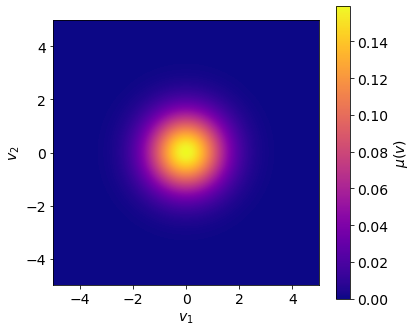

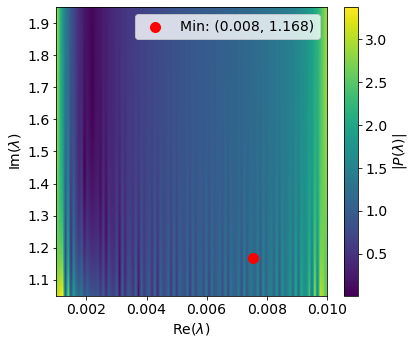

In [3]:
## Plot gaussian equilibrium and compute Penrose cond P(k,lambda)
# gaussian, using python function quad

def mu(v1, v2, theta):
    return (1 / (2 * np.pi * theta)) * np.exp(- (v1**2 + v2**2) / (2*theta))

v1 = np.linspace(-5, 5, 400)
v2 = np.linspace(-5, 5, 400)
V1, V2 = np.meshgrid(v1, v2)
theta = 1
Z = mu(V1, V2, theta)

fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(Z.T, extent=(v1[0], v1[-1], v2[0], v2[-1]), cmap='plasma', interpolation='bilinear')
cbar = fig.colorbar(im, ax=ax)
cbar.set_label(r"$\mu(v)$")
ax.set_xlabel(r"$v_1$")
ax.set_ylabel(r"$v_2$")
#plt.savefig('Gaussian_theta1-refine.png')
fig.tight_layout()

# Compute P(k,\lambda)
def integral(lambda_R, lambda_I):
    integrand = lambda t: np.exp(-lambda_R * t) * (np.cos(lambda_I * t) - 1j * np.sin(lambda_I * t)) * np.exp(np.cos(t)) * np.sin(t)
    result, _ = integrate.quad(lambda t: integrand(t).real, 0, 400, limit = 200)  # Real part
    result_imag, _ = integrate.quad(lambda t: integrand(t).imag, 0, 400, limit = 200)  # Imaginary part
    return np.sqrt((1 + np.exp(-1) * result)**2 + (np.exp(-1) * result_imag)**2)

lambda_R = np.linspace(0.001, 0.01, 200)
lambda_I = np.linspace(1.05, 1.95, 100)
Lambda_R, Lambda_I = np.meshgrid(lambda_R, lambda_I)

P_norm = np.zeros_like(Lambda_R, dtype=np.float64)
for i in range(Lambda_R.shape[0]):
    for j in range(Lambda_R.shape[1]):
        P_norm[i, j] = np.abs(integral(Lambda_R[i, j], Lambda_I[i, j]))

min_index = np.unravel_index(np.argmin(P_norm), P_norm.shape)
lambda_R_min = Lambda_R[min_index]
lambda_I_min = Lambda_I[min_index]
P_min_value = P_norm[min_index]

fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(P_norm.T, origin='lower', extent=(lambda_R[0], lambda_R[-1], lambda_I[0], lambda_I[-1]),
               cmap="viridis", aspect='auto', interpolation='bilinear')
cbar = fig.colorbar(im, ax=ax)
cbar.set_label(r"$|P(\lambda)|$")
ax.set_xlabel(r"Re($\lambda$)")
ax.set_ylabel(r"Im($\lambda$)")
plt.scatter(lambda_R_min, lambda_I_min, color='red', marker='o', s=100, label=f'Min: ({lambda_R_min:.3f}, {lambda_I_min:.3f})')
plt.legend()
#plt.savefig('Gaussian_theta1_Penrose_Lam1_2.png')
fig.tight_layout()

(lambda_R_min, lambda_I_min, P_min_value) 

(0.001, 1.1642857142857144, 0.0019516622741895411)

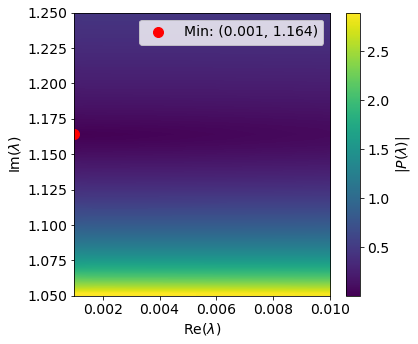

In [4]:
# gaussian, using numerical integration with trapezoidal rule

T_max = 5000
N = 1000000
t = np.linspace(0, T_max, N)
dt = t[1] - t[0]

B0 = 1
theta = 1
ksq = 1

lambda_R = np.linspace(0.001, 0.01, 50)
lambda_I = np.linspace(1.05, 1.25, 50)
Lambda_R, Lambda_I = np.meshgrid(lambda_R, lambda_I)
P_norm = np.zeros_like(Lambda_R, dtype=np.float64)

sin_term = np.sin(t)
z = 1 - np.cos(t)

for i in range(P_norm.shape[0]): # Compute P for each lambda using trapezoidal rule
    for j in range(P_norm.shape[1]):
        lam = lambda_R[j] + 1j * lambda_I[i]
        exp_term = np.exp(- lam * t - z)
        integrand = exp_term * sin_term
        integral = np.trapz(integrand, t)
        P_norm[i, j] = np.abs(1 + integral)

min_index = np.unravel_index(np.argmin(P_norm), P_norm.shape)
lambda_R_min = Lambda_R[min_index]
lambda_I_min = Lambda_I[min_index]
P_min_value = P_norm[min_index]
   
fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(P_norm, origin='lower', extent=(lambda_R[0], lambda_R[-1], lambda_I[0], lambda_I[-1]),
               cmap="viridis", aspect='auto', interpolation='bilinear')
cbar = fig.colorbar(im, ax=ax)
cbar.set_label(r"$|P(\lambda)|$")
ax.set_xlabel(r"Re($\lambda$)")
ax.set_ylabel(r"Im($\lambda$)")
plt.scatter(lambda_R_min, lambda_I_min, color='red', marker='o', s=100, label=f'Min: ({lambda_R_min:.3f}, {lambda_I_min:.3f})')
plt.legend()
#plt.savefig('Gaussian_theta1_Penrose_Lam1_1pt25.png')
fig.tight_layout()

(lambda_R_min, lambda_I_min, P_min_value)

(0.00594949494949495, 1.0207070707070707, 1.5115015855910933e-05)

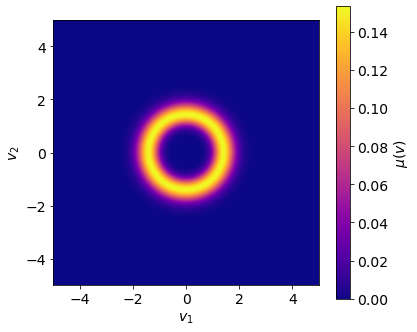

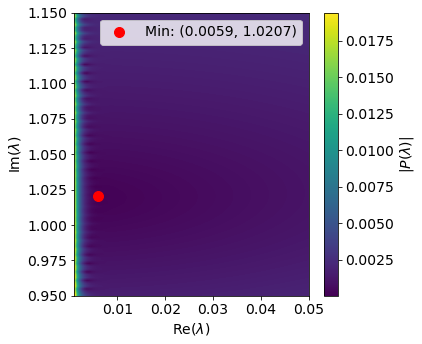

In [30]:
## Graph DGH equilibrium and compute Penrose
# use trapezoidal rule

v1 = np.linspace(-5, 5, 400)
v2 = np.linspace(-5, 5, 400)
V1, V2 = np.meshgrid(v1, v2)

def f_DGH6(vx, vy):
    coeff = 243 / (jnp.pi * 80) 
    vr = vx**2 + vy**2
    f_exp = jnp.exp(- 3*vr)
    f_rad = vr ** 6
    return coeff * f_rad * f_exp  

Z = f_DGH6(V1, V2)
fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(Z.T, extent=(v1[0], v1[-1], v2[0], v2[-1]), cmap='plasma', interpolation='bilinear')
cbar = fig.colorbar(im, ax=ax)
cbar.set_label(r"$\mu(v)$")
ax.set_xlabel(r"$v_1$")
ax.set_ylabel(r"$v_2$")
#plt.savefig('DGH6.png')
fig.tight_layout()

k_sq = 0.01
B0 = 0.05
j = 6
T_max = 1000
N = 500000
t = np.linspace(0, T_max, N)
dt = t[1] - t[0]

cos_B0t, sin_B0t = np.cos(B0 * t), np.sin(B0 * t)
z = (1/6) * k_sq * (1 - cos_B0t) * (1 / B0**2) 
sin_term = sin_B0t / B0

def M_series(z):
    return (1 - 6*z + (15/2)*z**2 - (10/3)*z**3 + (5/8)*z**4 - (1/20)*z**5 + (1/720)*z**6)

M_vals = M_series(z)

lambda_R_values = np.linspace(0.001, 0.05, 100)
lambda_I_values = np.linspace(0.95, 1.15, 100)
lambda_grid_R, lambda_grid_I = np.meshgrid(lambda_R_values, lambda_I_values)
lambda_grid = lambda_grid_R + 1j * lambda_grid_I

P_vals = np.zeros_like(lambda_grid, dtype=np.complex128)

for i in range(lambda_grid.shape[0]): # Compute P for each lambda using trapezoidal rule
    for j in range(lambda_grid.shape[1]):
        lam = lambda_grid[i, j]
        exp_term = np.exp(-lam * t - z)
        integrand = exp_term * M_vals * sin_term
        integral = np.trapz(integrand, t)
        P_vals[i, j] = k_sq * (1 + integral)

results = np.abs(P_vals)       
min_index = np.unravel_index(np.argmin(results), results.shape)
lambda_I_min = lambda_I_values[min_index[0]]
lambda_R_min = lambda_R_values[min_index[1]]
P_min_value = results[min_index]

fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(results, origin='lower', extent=(lambda_R_values[0], lambda_R_values[-1], 
                                                 lambda_I_values[0], lambda_I_values[-1]),
               cmap="viridis", aspect='auto', interpolation='bilinear')
cbar = fig.colorbar(im, ax=ax)
cbar.set_label(r"$|P(\lambda)|$")
ax.set_xlabel(r"Re$(\lambda)$")
ax.set_ylabel(r"Im$(\lambda)$")
plt.scatter(lambda_R_min, lambda_I_min, color='red', marker='o', s=100, label=f'Min: ({lambda_R_min:.4f}, {lambda_I_min:.4f})')
plt.legend()
#plt.savefig('Penrose_DGH6_ksq1.png')
fig.tight_layout()

(lambda_R_min, lambda_I_min, P_min_value) 

(0, 0)
(0, 1)
(0, 2)
(0, 3)
(0, 4)
(1, 0)
(1, 1)
(1, 2)
(1, 3)
(1, 4)
(2, 0)
(2, 1)
(2, 2)
(2, 3)
(2, 4)
(3, 0)
(3, 1)
(3, 2)
(3, 3)
(3, 4)
(4, 0)
(4, 1)
(4, 2)
(4, 3)
(4, 4)
(5, 0)
(5, 1)
(5, 2)
(5, 3)
(5, 4)
(6, 0)
(6, 1)
(6, 2)
(6, 3)
(6, 4)
(7, 0)
(7, 1)
(7, 2)
(7, 3)
(7, 4)
(8, 0)
(8, 1)
(8, 2)
(8, 3)
(8, 4)
(9, 0)
(9, 1)
(9, 2)
(9, 3)
(9, 4)


(0.007444444444444444, 1.0, 0.0004476380009339045)

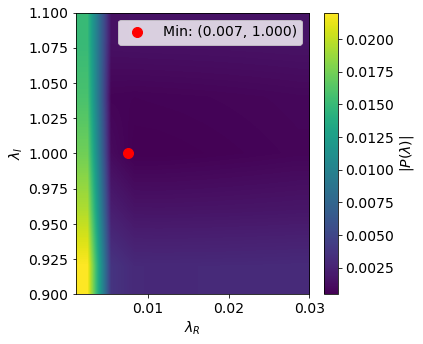

In [17]:
# use python function quad

lambda_R_values = np.linspace(0.001, 0.03, 10)  
lambda_I_values = np.linspace(0.9, 1.1, 5) 

results = np.zeros((len(lambda_R_values), len(lambda_I_values)), dtype=complex)

def real_integrand(t, lambda_R, lambda_I, j):
    arg = -((1 - np.cos(B0 * t))/(B0**2)) * k_squared / j
    M = hyp1f1(j + 1, 1, arg)
    return np.exp(-lambda_R * t) * np.cos(-lambda_I * t) * M * np.sin(B0 * t)

def imag_integrand(t, lambda_R, lambda_I, j):
    arg = -((1 - np.cos(B0 * t))/(B0**2)) * k_squared / j #-(1 - np.cos(B0 * t)) * k_squared / j
    M = hyp1f1(j + 1, 1, arg)
    return np.exp(-lambda_R * t) * np.sin(-lambda_I * t) * M * np.sin(B0 * t)

for i, lambda_R in enumerate(lambda_R_values):
    for j_, lambda_I in enumerate(lambda_I_values):
        real_part, _ = quad(real_integrand, 0, T_max, args=(lambda_R, lambda_I, j), limit=300, epsabs=1e-10)
        imag_part, _ = quad(imag_integrand, 0, T_max, args=(lambda_R, lambda_I, j), limit=300, epsabs=1e-10)
        integral = (real_part + 1j * imag_part) / B0
        I = k_squared + k_squared * integral
        results[i, j_] = I

results = np.abs(results)       
min_index = np.unravel_index(np.argmin(results), results.shape)
lambda_R_min = lambda_R_values[min_index[0]]
lambda_I_min = lambda_I_values[min_index[1]]
P_min_value = results[min_index]

fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(results.T, origin='lower', extent=(lambda_R_values[0], lambda_R_values[-1], 
                                                 lambda_I_values[0], lambda_I_values[-1]),
               cmap="viridis", aspect='auto', interpolation='bilinear')
cbar = fig.colorbar(im, ax=ax)
cbar.set_label(r"$|P(\lambda)|$")
ax.set_xlabel(r"$\lambda_R$")
ax.set_ylabel(r"$\lambda_I$")
plt.scatter(lambda_R_min, lambda_I_min, color='red', marker='o', s=100, label=f'Min: ({lambda_R_min:.3f}, {lambda_I_min:.3f})')
plt.legend()
#plt.savefig('Penrose_DGH6_ksq1.png')
fig.tight_layout()

(lambda_R_min, lambda_I_min, P_min_value) 

In [3]:
## FREE-STREAM SOLVER

@partial(jit, static_argnums=(6, 7))
def run_solver_free_streaming(
    f_iv,
    grid_x,
    grid_y,
    grid_vx,
    grid_vy,
    delta_t,
    N_steps,
    N_snaps,
    k_track,
    B_external
):
    """ 
    Free update Sequence (new):
        1. Hf_update by delta_t / 2
        2. HB_update by delta_t / 2
        3. Solve Poisson equation for E
        4. HB_update by delta_t / 2
        5. Hf_update by delta_t / 2
    """
    dx, dy = grid_x[1] - grid_x[0], grid_y[1] - grid_y[0] # Compute grid spacings
    dvx, dvy = grid_vx[1] - grid_vx[0], grid_vy[1] - grid_vy[0]
    k, m = k_track

    rho = compute_rho(f_iv, dvx, dvy)  # [N_x, N_y]
    U, E_x, E_y = solve_poisson_2d(rho, grid_x, grid_y, dx, dy)  # Solve Poisson equation, [N_x, N_y]
    
    KE = compute_kinetic_energy_2D2D(f_iv, grid_vx, grid_vy, dvx, dvy, dx, dy)  # initial KE and EE, Scalar
    EE = compute_electric_energy_2D2D(E_x, E_y, dx, dy) 

    E_x_hat, E_y_hat = jnp.fft.fft2(E_x), jnp.fft.fft2(E_y) # initial FT of electric fields, [N_x, N_y]
    E_x_mode, E_y_mode = E_x_hat[k, m], E_y_hat[k, m]  # specified Fourier modes, scalar (complex)

    history_rho_initial = jnp.array([rho]) # initial step
    history_U_initial = jnp.array([U])
    history_E_initial = jnp.stack([E_x, E_y], axis=-1)[None, ...]  # [1, N_x, N_y, 2]
    history_KE_initial, history_EE_initial = jnp.array([KE]), jnp.array([EE])    
    history_Fourier_initial = jnp.stack([E_x_mode, E_y_mode], axis=-1)[None, ...]  # [1, 2]
    
    snapshot_indices = jnp.linspace(0, N_steps - 1, N_snaps, dtype=int)
    snapshot_list = jnp.zeros((N_snaps,) + f_iv.shape)
    f_last_snap = jnp.zeros((1,) + f_iv.shape)
    rho_snaps_list = jnp.zeros((N_snaps,) + rho.shape)
    Ey_snaps_list = jnp.zeros((N_snaps,) + E_x.shape)

    def step_fn(carry, i): # step function for Strang splitting with magnetic field
        
        f_current, E_x_current, E_y_current, snapshot_list, rho_snaps_list, Ey_snaps_list, f_slice_list, fx_vx, rho_xy, f_last_snap = carry  

        f_half, _ = Hf_update(grid_x, grid_y, grid_vx, grid_vy, f_current, delta_t / 2) 

        #f_half = HB_update(grid_x, grid_y, grid_vx, grid_vy, f_half, B_external, delta_t) # [N_x, N_y, N_vx, N_vy]
        #f_new, _ = Hf_update(grid_x, grid_y, grid_vx, grid_vy, f_half, delta_t / 2)
        
        f_1st_half = HB_update(grid_x, grid_y, grid_vx, grid_vy, f_half, B_external, delta_t / 2)
        rho_half = compute_rho(f_1st_half, dvx, dvy)  # [N_x, N_y]
        U_half, Ex_half, Ey_half = solve_poisson_2d(rho_half, grid_x, grid_y, dx, dy)  
        E_half = jnp.stack([Ex_half, Ey_half], axis=-1)
        f_2nd_half = HB_update(grid_x, grid_y, grid_vx, grid_vy, f_1st_half, B_external, delta_t / 2)
        f_new, _ = Hf_update(grid_x, grid_y, grid_vx, grid_vy, f_2nd_half, delta_t / 2)

        rho_new = compute_rho(f_new, dvx, dvy)  # [N_x, N_y]
        U_new, E_x_new, E_y_new = solve_poisson_2d(rho_new, grid_x, grid_y, dx, dy)  # [N_x, N_y]
        
        E_x_hat_new, E_y_hat_new = jnp.fft.fft2(E_x_new), jnp.fft.fft2(E_y_new)  # FT, [N_x, N_y]
        E_x_mode_new, E_y_mode_new = E_x_hat_new[k, m], E_y_hat_new[k, m]  # specified modes, Scalar (complex)

        KE_new = compute_kinetic_energy_2D2D(f_new, grid_vx, grid_vy, dvx, dvy, dx, dy)  # KE, Scalar
        EE_new = compute_electric_energy_2D2D(E_x_new, E_y_new, dx, dy) # EE
        Fourier_new = jnp.stack([E_x_mode_new, E_y_mode_new], axis=-1)  # Shape: [2]
        E_new = jnp.stack([E_x_new, E_y_new], axis=-1)  # Shape: [N_x, N_y, 2]  
        
        index = jnp.clip(jnp.searchsorted(snapshot_indices, i), 0, N_snaps - 1)
        snapshot_list = lax.cond(jnp.any(snapshot_indices == i),
            lambda _: snapshot_list.at[index].set(f_new),
            lambda _: snapshot_list, operand=None) # Store f(x, v) snapshots 
        
        rho_snaps_list = lax.cond(jnp.any(snapshot_indices == i),
            lambda _: rho_snaps_list.at[index].set(rho_new),
            lambda _: rho_snaps_list, operand=None) # Store rho(x) snapshots 
        
        Ey_snaps_list = lax.cond(jnp.any(snapshot_indices == i),
            lambda _: Ey_snaps_list.at[index].set(E_x_new),
            lambda _: Ey_snaps_list, operand=None) # Store electric energy Ey
        
        f_last_snap = lax.cond(jnp.any(N_steps - 2 == i),
            lambda _: f_last_snap.at[0].set(f_new),
            lambda _: f_last_snap, operand=None) 
        
        f_slice_list = f_slice_list.at[i+1].set(f_new[1,1,:,:])
        fx_vx = fx_vx.at[i+1].set(f_new[:,0,:,32])
        rho_xy = rho_xy.at[i+1].set(rho_new)
    
        return (f_new, E_x_new, E_y_new, snapshot_list, rho_snaps_list, Ey_snaps_list, f_slice_list, fx_vx, rho_xy, f_last_snap), \
               (rho_new, E_half, U_new, KE_new, EE_new, Fourier_new)

    f_slice_list = jnp.zeros((N_steps+1, grid_vx.shape[0], grid_vy.shape[0]))
    f_slice_list = f_slice_list.at[0].set(f_iv[1,1,:,:])
    
    fx_vx = jnp.zeros((N_steps+1, grid_x.shape[0], grid_vx.shape[0]))
    fx_vx = fx_vx.at[0].set(f_iv[:,0,:,32])
    
    rho_xy = jnp.zeros((N_steps+1, grid_x.shape[0], grid_y.shape[0]))
    rho_xy = rho_xy.at[0].set(rho)

    carry_init = (f_iv, E_x, E_y, snapshot_list, rho_snaps_list, Ey_snaps_list, f_slice_list, fx_vx, rho_xy, f_last_snap)
    carry_final, scan_outputs = lax.scan(step_fn, carry_init, jnp.arange(N_steps)) # Run solver

    f_final, _, _, f_snaps, rho_snaps, Ey_snaps, f_slices, fx_vx, rho_xy, f_last_snap = carry_final
    rho_new_steps, E_new_steps, U_new_steps, KE_steps, EE_steps, Fourier_steps = scan_outputs

    history_rho_steps = rho_new_steps  
    history_rho_total = jnp.concatenate([history_rho_initial, history_rho_steps], axis=0)
    
    history_U_steps = U_new_steps
    history_U_total = jnp.concatenate([history_U_initial, history_U_steps], axis=0)
    
    history_E_steps = E_new_steps  
    history_E_total = jnp.concatenate([history_E_initial, history_E_steps], axis=0)  # [1 + N_steps, N_x, N_y, 2]

    history_KE_steps = KE_steps  # [N_steps]
    history_KE_total = jnp.concatenate([history_KE_initial, history_KE_steps], axis=0)  # [1 + N_steps]

    history_EE_steps = EE_steps  # [N_steps]
    history_EE_total = jnp.concatenate([history_EE_initial, history_EE_steps], axis=0)  # Shape: [1 + N_steps]

    history_Fourier_steps = Fourier_steps  # [N_steps, 2]
    history_Fourier_total = jnp.concatenate([history_Fourier_initial, history_Fourier_steps], axis=0)  #[1+N_steps, 2]
    
    return (f_final, f_slices, fx_vx, rho_xy, f_snaps, rho_snaps, Ey_snaps, 
            history_rho_total, history_E_total, history_U_total, history_KE_total, 
            history_EE_total, history_Fourier_total, f_last_snap)
    

In [4]:
### NONLINEAR SOLVER

@partial(jit, static_argnums=(6, 7))
def run_solver_with_magnetic_field_history(
    f_iv,
    grid_x,
    grid_y,
    grid_vx,
    grid_vy,
    delta_t,
    N_steps,
    N_snaps,
    k_track,
    Hx,
    Hy,
    B_external
):
    """
    splitting:
    1. Hf_update by delta t/2
    2. HB_update by delta t/2
    3. solve Poisson
       HE_update by delta t 
    4. HB_update by delta t/2
    5. Hf_update by delta t/2
    """
    dx = grid_x[1] - grid_x[0]
    dy = grid_y[1] - grid_y[0]
    dvx = grid_vx[1] - grid_vx[0]
    dvy = grid_vy[1] - grid_vy[0]

    k, m = k_track 

    rho = compute_rho(f_iv, dvx, dvy)  # Initial charge density and electric fields
    _, E_x, E_y = solve_poisson_2d(rho, grid_x, grid_y, dx, dy)
    KE = compute_kinetic_energy_2D2D(f_iv, grid_vx, grid_vy, dvx, dvy, dx, dy)
    EE = compute_electric_energy_2D2D(E_x, E_y, dx, dy)

    E_x_hat, E_y_hat = jnp.fft.fft2(E_x), jnp.fft.fft2(E_y)
    E_x_mode, E_y_mode = E_x_hat[k, m], E_y_hat[k, m]

    history_E = jnp.stack([E_x, E_y], axis=-1)[None, ...]
    history_KE, history_EE = jnp.array([KE]), jnp.array([EE])
    history_Fourier = jnp.stack([E_x_mode, E_y_mode], axis=-1)[None, ...]

    snapshot_indices = jnp.linspace(0, N_steps - 1, N_snaps, dtype=int)  # Compute snapshot indices
    snapshot_list = jnp.zeros((N_snaps,) + f_iv.shape)  # Storage for snapshots
    rho_snaps_list = jnp.zeros((N_snaps,) + rho.shape)
    Ey_snaps_list = jnp.zeros((N_snaps,) + E_x.shape)

    def step_fn(carry, i):
        f_current, E_x_current, E_y_current, snapshot_list, rho_snaps_list, Ey_snaps_list, f_slice, fx_vx, rho_xy= carry
            # Hf update: dt/2
        f_half, _ = Hf_update(grid_x, grid_y, grid_vx, grid_vy, f_current, delta_t / 2)
            # HB update: dt/2
        f_half = HB_update(grid_x, grid_y, grid_vx, grid_vy, f_half, B_external, delta_t / 2)
            # HE update: dt
        rho_new = compute_rho(f_half, dvx, dvy) # Solve Poisson equation
        _, E_x_new, E_y_new = solve_poisson_2d(rho_new, grid_x, grid_y, dx, dy)
        f_new = HE_update(grid_vx, grid_vy, f_half, E_x_new, E_y_new, Hx, Hy, delta_t)
            # HB update: dt/2
        f_new = HB_update(grid_x, grid_y, grid_vx, grid_vy, f_new, B_external, delta_t / 2)
            # Hf update: dt/2
        f_new, _ = Hf_update(grid_x, grid_y, grid_vx, grid_vy, f_new, delta_t / 2)

        rho_final = compute_rho(f_new, dvx, dvy)
        _, E_x_final, E_y_final = solve_poisson_2d(rho_final, grid_x, grid_y, dx, dy)

        KE_new = compute_kinetic_energy_2D2D(f_new, grid_vx, grid_vy, dvx, dvy, dx, dy)
        EE_new = compute_electric_energy_2D2D(E_x_final, E_y_final, dx, dy)
        E_x_hat_new, E_y_hat_new = jnp.fft.fft2(E_x_final), jnp.fft.fft2(E_y_final)
        E_x_mode_new, E_y_mode_new = E_x_hat_new[k, m], E_y_hat_new[k, m]

        E_new = jnp.stack([E_x_final, E_y_final], axis=-1) # Stack electric field and Fourier modes
        Fourier_new = jnp.stack([E_x_mode_new, E_y_mode_new], axis=-1)
        
        index = jnp.clip(jnp.searchsorted(snapshot_indices, i), 0, N_snaps - 1)
        snapshot_list = lax.cond(
            jnp.any(snapshot_indices == i),
            lambda _: snapshot_list.at[index].set(f_new), lambda _: snapshot_list, 
            operand=None) # Store f(x, v) snapshots at specified intervals
        
        rho_snaps_list = lax.cond(
            jnp.any(snapshot_indices == i),
            lambda _: rho_snaps_list.at[index].set(rho_final), lambda _: rho_snaps_list, 
            operand=None) # Store rho(x) snapshots at specified intervals
        
        Ey_snaps_list = lax.cond(
            jnp.any(snapshot_indices == i),
            lambda _: Ey_snaps_list.at[index].set(E_x_final), lambda _: Ey_snaps_list,
            operand=None) # Store electric energy Ex
        
        f_slice = f_slice.at[i+1].set(f_new[1,1,:,:])
        fx_vx = fx_vx.at[i+1].set(f_new[:,32,:,32])
        rho_xy = rho_xy.at[i+1].set(rho_final)
    
        return (f_new, E_x_final, E_y_final, snapshot_list, rho_snaps_list, Ey_snaps_list, f_slice, fx_vx, rho_xy), \
               (E_new, KE_new, EE_new, Fourier_new)
    
    f_slice = jnp.zeros((N_steps+1, grid_vx.shape[0], grid_vy.shape[0]))
    f_slice = f_slice.at[0].set(f_iv[1,1,:,:])
    
    fx_vx = jnp.zeros((N_steps+1, grid_x.shape[0], grid_vx.shape[0]))
    fx_vx = fx_vx.at[0].set(f_iv[:,32,:,32])
    
    rho_xy = jnp.zeros((N_steps+1, grid_x.shape[0], grid_y.shape[0]))
    rho_xy = rho_xy.at[0].set(rho)

    carry_init = (f_iv, E_x, E_y, snapshot_list, rho_snaps_list, Ey_snaps_list, f_slice, fx_vx, rho_xy)  # IC

    carry_final, scan_outputs = lax.scan(step_fn, carry_init, jnp.arange(N_steps)) # Run solver

    f_final, _, _, f_snapshots, rho_snapshots, Ey_snapshots, f_slices, fx_vx, rho_xy = carry_final
    fx_vx_vy = jnp.zeros((1, grid_x.shape[0], grid_vx.shape[0], grid_vy.shape[0]))
    fx_vx_vy = fx_vx_vy.at[0].set(f_final[:,1,:,:])
    
    E_new_steps, KE_steps, EE_steps, Fourier_steps = scan_outputs

    history_E = jnp.concatenate([history_E, E_new_steps], axis=0) # Concatenate initial state with history
    history_KE = jnp.concatenate([history_KE, KE_steps], axis=0)
    history_EE = jnp.concatenate([history_EE, EE_steps], axis=0)
    history_Fourier = jnp.concatenate([history_Fourier, Fourier_steps], axis=0)

    return (f_final, f_slices, fx_vx, fx_vx_vy, rho_xy, f_snapshots, rho_snapshots, Ey_snapshots, 
            history_E, history_KE, history_EE, history_Fourier)


In [5]:
## CONTROL SOLVER: take in control electric field H(t)

@partial(jit, static_argnums=(6, 7))

def run_solver_with_external_field_H(
    f_iv,
    grid_x,
    grid_y,
    grid_vx,
    grid_vy,
    delta_t,
    N_steps,
    N_snaps,
    k_track,
    Hx,  
    Hy,  
    B_external
):
    '''
    Cotnrol update sequence:
    1. Hf_update by delta_t / 2
    2. HB_update by delta_t / 2
    3. Solve Poisson equation to get Ex and Ey
    4. HE_update by delta_t
    5. HB_update by delta_t / 2
    6. Hf_update by delta_t / 2
    '''
    
    dx, dy = grid_x[1] - grid_x[0], grid_y[1] - grid_y[0]
    dvx, dvy = grid_vx[1] - grid_vx[0], grid_vy[1] - grid_vy[0]
    k, m = k_track 

    rho = compute_rho(f_iv, dvx, dvy)  # Initial charge density, Shape: [N_x, N_y]
    _, E_x, E_y = solve_poisson_2d(rho, grid_x, grid_y, dx, dy)  # initial electric fields, Each Shape: [N_x, N_y]
    
    KE = compute_kinetic_energy_2D2D(f_iv, grid_vx, grid_vy, dvx, dvy, dx, dy)  # Scalar
    EE = compute_electric_energy_2D2D(E_x, E_y, dx, dy)  # Scalar

    E_x_hat, E_y_hat = jnp.fft.fft2(E_x), jnp.fft.fft2(E_y)  # [N_x, N_y]
    E_x_mode, E_y_mode = E_x_hat[k, m], E_y_hat[k, m]  # specified Fourier modes, Scalar (complex)

    history_E_initial = jnp.stack([E_x, E_y], axis=-1)[None, ...]  # Shape: [1, N_x, N_y, 2]
    history_KE_initial, history_EE_initial = jnp.array([KE]), jnp.array([EE]) 
    history_Fourier_initial = jnp.stack([E_x_mode, E_y_mode], axis=-1)[None, ...]  # Shape: [1, 2]
    
    KE = compute_kinetic_energy_2D2D(f_iv, grid_vx, grid_vy, dvx, dvy, dx, dy) # initial KE and EE
    EE = compute_electric_energy_2D2D(E_x, E_y, dx, dy)

    snapshot_indices = jnp.linspace(0, N_steps - 1, N_snaps, dtype=int)
    snapshot_list = jnp.zeros((N_snaps,) + f_iv.shape)  # Storage for snapshots
    rho_snapshot_list = jnp.zeros((N_snaps,) + rho.shape)
    Ey_snapshot_list = jnp.zeros((N_snaps,) + E_y.shape)

    def step_fn(carry, t_step):
    
        f_current, E_x_current, E_y_current, snapshot_list, rho_snapshot_list, Ey_snapshot_list, f_slice_list, fx_vx_list, rho_xy = carry # Unpack the carry 

        Hx_t, Hy_t = Hx[t_step], Hy[t_step]   # external electric field for current time step

        f_half, _ = Hf_update(grid_x, grid_y, grid_vx, grid_vy, f_current, delta_t / 2)

        f_half = HB_update(grid_x, grid_y, grid_vx, grid_vy, f_half, B_external, delta_t / 2)

        rho_new = compute_rho(f_half, dvx, dvy)  # [N_x, N_y]
        _, E_x_new, E_y_new = solve_poisson_2d(rho_new, grid_x, grid_y, dx, dy)  # [N_x, N_y]
        
        f_new = HE_update(grid_vx, grid_vy, f_half, E_x_new, E_y_new, Hx_t, Hy_t, delta_t)# Shape: [N_x, N_y, N_vx, N_vy]

        f_new = HB_update(grid_x, grid_y, grid_vx, grid_vy, f_new, B_external, delta_t / 2)# Shape: [N_x, N_y, N_vx, N_vy]

        f_new, _ = Hf_update(grid_x, grid_y, grid_vx, grid_vy, f_new, delta_t / 2) 

        rho_final = compute_rho(f_new, dvx, dvy)  # Shape: [N_x, N_y]
        _, E_x_final, E_y_final = solve_poisson_2d(rho_final, grid_x, grid_y, dx, dy)  # Shape: [N_x, N_y]

        KE_new = compute_kinetic_energy_2D2D(f_new, grid_vx, grid_vy, dvx, dvy, dx, dy)  
        EE_new = compute_electric_energy_2D2D(E_x_final, E_y_final, dx, dy) 

        # Compute Fourier transforms of updated electric fields
        E_x_hat_new, E_y_hat_new = jnp.fft.fft2(E_x_final), jnp.fft.fft2(E_y_final)  # Shape: [N_x, N_y]
        E_x_mode_new, E_y_mode_new = E_x_hat_new[k, m], E_y_hat_new[k, m]  # Fourier modes, Scalar (complex)

        E_new = jnp.stack([E_x_final, E_y_final], axis=-1)
        Fourier_new = jnp.stack([E_x_mode_new, E_y_mode_new], axis=-1)
        
        index = jnp.clip(jnp.searchsorted(snapshot_indices, t_step), 0, N_snaps - 1)
        snapshot_list = lax.cond(
            jnp.any(snapshot_indices == t_step),
            lambda _: snapshot_list.at[index].set(f_new),
            lambda _: snapshot_list,
            operand=None) # Store f(x, v) snapshots at specified intervals
        
        rho_snapshot_list = lax.cond(
            jnp.any(snapshot_indices == t_step),
            lambda _: rho_snapshot_list.at[index].set(rho_final),
            lambda _: rho_snapshot_list,
            operand=None) # Store rho(x) snapshots at specified intervals
        
        Ey_snapshot_list = lax.cond(
            jnp.any(snapshot_indices == t_step),
            lambda _: Ey_snapshot_list.at[index].set(E_x_final),
            lambda _: Ey_snapshot_list,
            operand=None)
        
        Fourier_new = jnp.stack([E_x_mode_new, E_y_mode_new], axis=-1)  # Shape: [2]
        E_new = jnp.stack([E_x_final, E_y_final], axis=-1)  # Shape: [N_x, N_y, 2]
        
        f_slice_list = f_slice_list.at[t_step+1].set(f_new[1,1,:,:])
        fx_vx_list = fx_vx_list.at[t_step+1].set(f_new[:,0,:,32])
        rho_xy = rho_xy.at[t_step+1].set(rho_final)

        new_carry = (f_new, E_x_final, E_y_final, snapshot_list, rho_snapshot_list, Ey_snapshot_list, f_slice_list, fx_vx_list, rho_xy)
        output = (E_new, KE_new, EE_new, Fourier_new)
        
        return new_carry, output
    
    f_slice_list = jnp.zeros((N_steps+1, grid_vx.shape[0], grid_vy.shape[0]))
    f_slice_list = f_slice_list.at[0].set(f_iv[1,1,:,:])
    
    fx_vx_list = jnp.zeros((N_steps+1, grid_x.shape[0], grid_vx.shape[0]))
    fx_vx_list = fx_vx_list.at[0].set(f_iv[:,0,:,32])
    
    rho_xy = jnp.zeros((N_steps+1, grid_x.shape[0], grid_y.shape[0]))
    rho_xy = rho_xy.at[0].set(rho)
    
    carry_init = (f_iv, E_x, E_y, snapshot_list, rho_snapshot_list, Ey_snapshot_list, f_slice_list, fx_vx_list, rho_xy) 

    carry_final, scan_outputs = lax.scan(step_fn, carry_init, jnp.arange(N_steps))

    f_final, _, _, f_snapshots, rho_snapshots, Ey_snapshots, f_slice, fx_vx, rho_xy = carry_final
    E_new_steps, KE_steps, EE_steps, Fourier_steps = scan_outputs

    history_E_steps = E_new_steps  # Shape: [N_steps, N_x, N_y, 2]
    history_E_total = jnp.concatenate([history_E_initial, history_E_steps], axis=0)  # Shape: [1 + N_steps, N_x, N_y, 2]

    history_KE_steps = KE_steps  # Shape: [N_steps]
    history_KE_total = jnp.concatenate([history_KE_initial, history_KE_steps], axis=0)  # Shape: [1 + N_steps]

    history_EE_steps = EE_steps  # Shape: [N_steps]
    history_EE_total = jnp.concatenate([history_EE_initial, history_EE_steps], axis=0)  # Shape: [1 + N_steps]

    history_Fourier_steps = Fourier_steps  # Shape: [N_steps, 2]
    history_Fourier_total = jnp.concatenate([history_Fourier_initial, history_Fourier_steps], axis=0)  # Fourier modes history: [1 + N_steps, 2]

    return (
        f_final,
        f_slice,
        fx_vx,
        rho_xy,
        f_snapshots, rho_snapshots, Ey_snapshots,
        history_E_total, history_KE_total, history_EE_total, history_Fourier_total,
    ) 


In [6]:
## Gallery of equilibrium \mu and possibly initial condition

def f_Gauss(theta, vx, vy):
    vr = vx**2 + vy**2
    gauss_v = (1 / (2 * jnp.pi * theta)) * jnp.exp(- vr/(2*theta))
    return gauss_v

def f_DGH(j, vx, vy): ## general DGH expression for j>=1
    coeff =  j / (2 * jnp.pi * math.factorial(j)) 
    vr = vx**2 + vy**2
    f_exp = jnp.exp(- (j * vr / 2))
    f_rad = (j * vr / 2) ** j
    return coeff * f_rad * f_exp

def f_DGH6(vx, vy):
    coeff = 243 / (jnp.pi * 80) 
    vr = vx**2 + vy**2
    f_exp = jnp.exp(- 3*vr)
    f_rad = vr ** 6
    return coeff * f_rad * f_exp

def f_DGH6_alpha(vx, vy): # DGH_6 instability: for general alpha_perp value
    alpha_sq = np.sqrt(2 / 6) ** 2
    coeff = 1 / (jnp.pi * alpha_sq * np.math.factorial(6)) 
    vr = vx**2 + vy**2
    f_exp = jnp.exp(- vr / alpha_sq)
    f_rad = (vr / alpha_sq) ** 6
    return coeff * f_rad * f_exp

def f_DGH6_phase(x, y, alpha, kx, vx, vy):
    coeff = 243 / (jnp.pi * 80) 
    vr = vx**2 + vy**2
    f_exp = jnp.exp(- 3*vr)
    f_rad = vr ** 6
    phase_theta = 4 * (jnp.arctan(vy/vx))
    f_perb_x = 1 + alpha * jnp.sin(phase_theta - kx * x)
    return coeff * f_rad * f_exp * f_perb_x


In [ ]:
### FREE-STREAMING SIMULATION

# 1. **Define Simulation Parameters**
kx, ky = 0.10, 0.10          # Wave number in x-direction
alpha = 0.001     # Perturbation amplitude in x
beta = 0.15      
domain_x, domain_y = 2.0 * jnp.pi / kx, 2.0 * jnp.pi / ky
N_x, N_y   = 64, 64            
N_vx, N_vy = 64, 64           
Vx_max, Vy_max = 5.0, 5.0    
delta_t = 0.1   
N_steps = 4000   
time_array = np.arange(N_steps + 1) * delta_t  # Shape: [N_steps +1]
N_snaps = 5
k_track = (1, 0)   # Fourier mode to track (k, m)
epsilon = 1e-10  # Small epsilon to prevent log(0)
    
# 2. **Generate Spatial and Velocity Grids**
x = jnp.linspace(-0.5*domain_x, 0.5*domain_x, N_x, endpoint=False)
y = jnp.linspace(-0.5*domain_y, 0.5*domain_y, N_y, endpoint=False)  
vx, vy = jnp.linspace(-Vx_max, Vx_max, N_vx), jnp.linspace(-Vy_max, Vy_max, N_vy)
dx, dy = x[1] - x[0], y[1] - y[0]
dvx, dvy = vx[1] - vx[0], vy[1] - vy[0]
    
# 3. **Create Meshgrids for Spatial and Velocity Coordinates**
X, Y = jnp.meshgrid(x, y, indexing='ij')       # [N_x, N_y]
VX, VY = jnp.meshgrid(vx, vy, indexing='ij')   # [N_vx, N_vy]
X_expanded, Y_expanded = X[:, :, None, None], Y[:, :, None, None]  # Expand for broadcasting: [N_x, N_y, 1, 1]
VX_expanded, VY_expanded = VX[None, None, :, :], VY[None, None, :, :]
    
#  4. Initial f_iv
#f_iv = (1 + alpha*jnp.sin(kx * X_expanded) + beta * jnp.cos(ky * Y_expanded)) * f_Gauss(1, VX_expanded, VY_expanded)  
f_iv = (1 + alpha*jnp.sin(kx * X_expanded)) * f_DGH6(VX_expanded, VY_expanded)  
#xr = X_expanded**2 + Y_expanded**2
#theta = 4
#gauss_x = (1 / (2 * jnp.pi * theta)) * jnp.exp(- xr/(2*theta))
#f_iv = (1 + 0.01*gauss_x)* f_DGH6(VX_expanded, VY_expanded)  
 
# 6. Define External Fields
Hx, Hy = jnp.zeros((N_x, N_y)), jnp.zeros((N_x, N_y)) # no external electric fields

B_0 = 0.05
B_external = jnp.ones((N_x, N_y)) * B_0  
    
# 7. **Run the free streaming Solver with Magnetic Field**
(f_final, f_slices, fx_vx, rho_xy, f_snaps, rho_snaps, Ey_snaps, history_rho_total,
 history_E, history_U, history_KE, history_EE, history_Fourier, _) = run_solver_free_streaming(
        f_iv,
        grid_x=x, grid_y=y, grid_vx=vx, grid_vy=vy,
        delta_t=delta_t, N_steps=N_steps, N_snaps=N_snaps, k_track=k_track, B_external=B_external)
    
# 8. Plots
history_E_np = np.array(history_E)      # Shape: [N_steps +1, N_x, N_y, 2]
history_KE_np, history_EE_np = np.array(history_KE), np.array(history_EE)   # [N_steps +1]
history_Fourier_np = np.array(history_Fourier)  # Shape: [N_steps +1, 2]
history_U_np = np.array(history_U)
fx_vx_np = np.array(fx_vx)
rho_xy_np = np.array(rho_xy)
f_slices_np = np.array(f_slices)

# 10. Define Decay Rate Fitting Parameters
t_start, t_end = 5, 300    
idx_start, idx_end = int(t_start / delta_t), int(t_end / delta_t) + 1 # Convert t_start and t_end to indices
    
# 11. **Plot Evolution of Electric Energy**
plt.figure(figsize=(10, 6))
plt.plot(time_array, history_EE_np)
plt.xlabel(r'$t$')
plt.ylabel(r'$\mathcal{E}$')
#plt.savefig('EE_free_DGH6_alpha0001_kx01_B_005.png')
#plt.title('Evolution of Electric Energy Over Time')
plt.grid(True)
plt.tight_layout()
plt.show()  
    
# **Add Semi-Log Plot for Electric Energy with Decay Rate**
plt.figure(figsize=(10, 6))
plt.semilogy(time_array, history_EE_np + epsilon, label='Electric Energy (Log Scale)')

log_EE = np.log(history_EE_np[idx_start:idx_end] + epsilon) # Fit semi-log decay between t_start and t_end
slope_EE, intercept_EE, _, _, _ = linregress(time_array[idx_start:idx_end], log_EE)
decay_rate_EE = -slope_EE  # Damping rate
fitted_EE = intercept_EE + slope_EE * time_array[idx_start:idx_end] # Generate fitted line

plt.plot(time_array[idx_start:idx_end], np.exp(fitted_EE), 'r--',
             label=f'Fit: decay rate = {decay_rate_EE:.4f}')
plt.xlabel(r'$t$')
plt.ylabel(r'$\log(\mathcal{E})$')
#plt.savefig('logEE_free_DGH6_alpha0001_kx01_B_005.png')
plt.legend()
#plt.title('Semi-Log Plot of Electric Energy Over Time')
plt.grid(True, which="both", ls="--")
plt.tight_layout()
plt.show()
print(f"Estimated Landau damping rate for Electric Energy: {decay_rate_EE:.4f}")

# **Plot Fourier Modes Evolution (Semi-Log Scale) with Decay Rates**
E_x_mode, E_y_mode = history_Fourier_np[:, 0], history_Fourier_np[:, 1]   # Shape: [N_steps +1]
E_x_modes_mag, E_y_modes_mag = np.abs(E_x_mode), np.abs(E_y_mode)

plt.figure(figsize=(10, 6))
plt.semilogy(time_array, E_x_modes_mag + epsilon, label=f'E_x Fourier Mode {k_track}')
plt.semilogy(time_array, E_y_modes_mag + epsilon, label=f'E_y Fourier Mode {k_track}')

log_E_x = np.log(E_x_modes_mag[idx_start:idx_end] + epsilon) # Fit log scale of E_x in (t_start, t_end) 
slope_E_x, intercept_E_x, _, _, _ = linregress(time_array[idx_start:idx_end], log_E_x)
decay_rate_E_x = -slope_E_x  # Damping rate

fitted_E_x = intercept_E_x + slope_E_x * time_array[idx_start:idx_end] # Generate fitted line
plt.plot(time_array[idx_start:idx_end], np.exp(fitted_E_x), 'r--',
             label=f'E_x Fit: decay rate = {decay_rate_E_x:.4f}')
    
log_E_y = np.log(E_y_modes_mag[idx_start:idx_end] + epsilon) # Fit log scale of E_y in (t_start, t_end)
slope_E_y, intercept_E_y, _, _, _ = linregress(time_array[idx_start:idx_end], log_E_y)
decay_rate_E_y = -slope_E_y  # Damping rate
fitted_E_y = intercept_E_y + slope_E_y * time_array[idx_start:idx_end] # Generate fitted line

plt.xlabel('Time')
plt.ylabel('Fourier Mode Magnitude (Log)')
plt.legend()
#plt.savefig('logFE_DGH6_free_DGH6_alpha0001_kx01_B_005.png')
plt.title(f'Semi-Log Plot of Fourier Modes at k={k_track}')
plt.grid(True, which="both", ls="--")
plt.tight_layout()
plt.show()
#print(f"Estimated Landau damping rate for E_x Fourier Mode: {decay_rate_E_x:.4f}")
#print(f"Estimated Landau damping rate for E_y Fourier Mode: {decay_rate_E_y:.4f}")

# 13. **Plot Evolution of Total Energy**
TE_np = history_KE_np + history_EE_np  # Shape: [N_steps +1]
    
plt.figure(figsize=(10, 6))
plt.plot(time_array, TE_np, label='Total Energy')
plt.xlabel(r'$t$')
plt.ylabel(r'$\mathcal{E}_{total}$')
#plt.savefig('TE_free_DGH6_alpha0001_kx01_B_005.png')
plt.title('Evolution of Total Energy Over Time')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()
    
# **Add Semi-Log Plot for Total Energy with Decay Rate**
plt.figure(figsize=(10, 6))
plt.semilogy(time_array, TE_np + epsilon, label='Total Energy (Log Scale)')
    
log_total_energy = np.log(TE_np[idx_start:idx_end] + epsilon) # Fit linear decay in log scale 
slope_total, intercept_total, _, _, _ = linregress(time_array[idx_start:idx_end], log_total_energy)
decay_rate_total = -slope_total  # Damping rate
    
fitted_total_energy = intercept_total + slope_total * time_array[idx_start:idx_end] # Generate fitted line
plt.plot(time_array[idx_start:idx_end], np.exp(fitted_total_energy), 'r--',
             label=f'Fit: decay rate = {decay_rate_total:.4f}')
plt.xlabel(r'$t$')
plt.ylabel(r'$\log(\mathcal{E}_{total})$')
#plt.savefig('logTE_free_DGH6_alpha0001_kx01_B_005.png')
plt.title('Semi-Log Plot of Total Energy Over Time')
plt.legend()
plt.grid(True, which="both", ls="--")
plt.tight_layout()
plt.show()
print(f"Estimated Landau damping rate for Total Energy: {decay_rate_total:.4f}")
    
# 14. **Plot Distribution Function at Selected (x, y) Points**
x0_idx, y0_idx = 1, 1
f_velocity_history = [] # List 

time_intervals = np.linspace(1, N_snaps, num=N_snaps, dtype=int)  
snapshot_indices = jnp.linspace(1, N_steps, N_snaps, dtype=int)

for t in time_intervals:
    f_velocity_history.append(f_snaps[t][x0_idx, y0_idx, :, :])  # Extract f(vx, vy)
f_velocity_history = np.array(f_velocity_history)  # Shape: [N_snaps, N_vx, N_vy]

fig, axes = plt.subplots(1, N_snaps, figsize=(25, 5)) # Plot evolution of velocity distribution at (x0, y0)
for i, ax in enumerate(axes.flatten()):
    ax.set_title(f'Time Step {snapshot_indices[i]}')
    im = ax.imshow(f_velocity_history[i].T, origin='lower', extent=(vx[0], vx[-1], vy[0], vy[-1]),
               cmap="plasma", aspect='auto', interpolation='bilinear')
    fig.colorbar(im, ax=ax)
    ax.set_xlabel(r'$v_x$')
    ax.set_ylabel(r'$v_y$')
plt.suptitle(f'Evolution of Velocity Distribution at (x={x[x0_idx]:.2f}, y={y[y0_idx]:.2f})')
#plt.savefig('f_snaps_free_DGH6_alpha0001_kx01_B_005.png')
plt.tight_layout()
plt.show()
    
fig, axes = plt.subplots(1, N_snaps, figsize=(25, 5)) 
for i in range(N_snaps):
    ax = axes[i]  # Select subplot
    im = ax.contourf(x, y, rho_snaps[i].T, cmap='viridis')  
    ax.set_xlabel(r'$x$')
    ax.set_ylabel(r'$y$')
    ax.set_title(f'Time Step {snapshot_indices[i]}')
    fig.colorbar(im, ax=ax, orientation='vertical')
plt.suptitle(r'Evolution of Density $\rho(x,y)$')
#plt.savefig('rho_snaps_free_DGH6_alpha0001_kx01_B_005.png')
plt.tight_layout()
plt.show()


In [ ]:
# Save output to file
np.save('history_E_free_Gauss_alpha000015_beta0015_kx04_ky1.npy', history_E_np)
np.save('history_KE_free_Gauss_alpha000015_beta0015_kx04_ky1.npy', history_KE_np)
np.save('history_EE_free_Gauss_alpha000015_beta0015_kx04_ky1.npy', history_EE_np)
np.save('history_Fourier_free_Gauss_alpha000015_beta0015_kx04_ky1.npy', history_Fourier_np)

np.save('f_final_free_Gauss_alpha000015_beta0015_kx04_ky1.npy', f_final_np)
np.save('f_iv_free_Gauss_alpha000015_beta0015_kx04_ky1.npy', f_iv_np)
np.save('fx_vx_free_Gauss_alpha000015_beta0015_kx04_ky1.npy', fx_vx_np)
np.save('rho_xy_free_Gauss_alpha000015_beta0015_kx04_ky1.npy', rho_xy_np)

In [ ]:
#### MOVIES
## distribution movie
f_slices_norm = []
for i in range(N_steps):
    f_now = f_slices_np[i]
    rho_now = jnp.sum(f_now, axis=(0, 1)) * dvx * dvy
    norm_f = f_now / rho_now
    f_slices_norm.append(np.array(norm_f))  # convert to np.array for matplotlib
f_slices_norm_np = np.array(f_slices_norm)

vmin = np.min(f_slices_norm_np)
vmax = np.max(f_slices_norm_np)

fig, ax = plt.subplots(figsize=(10, 8))
im = ax.imshow(f_slices_norm_np[0].T, origin='lower', extent=(vx[0], vx[-1], vy[0], vy[-1]),
               cmap="plasma", aspect='auto', vmin=vmin, vmax=vmax, interpolation='bilinear')
cbar = fig.colorbar(im, ax=ax)
cbar.set_label(r"$\bar{f}$")
ax.set_xlabel(r"$v_x$")
ax.set_ylabel(r"$v_y$")
ax.set_title(r"Evolution of $\bar{f}$")
fig.tight_layout()

def update(frame):
    im.set_data(f_slices_norm_np[frame].T)
    ax.set_title(f"Time step {frame}")
    return [im]
ani = animation.FuncAnimation(fig, update, frames=N_steps, interval=100, blit=True)
#ani.save("fv_evolve_free_DGH6_alpha005_k01_norm.mp4", writer="ffmpeg", dpi=200)
plt.show()

## slice movie
fx_vx_ic = fx_vx_np[0]

fig, ax = plt.subplots(figsize=(10, 8))
im = ax.imshow(fx_vx_ic.T, origin='lower', extent=(x[0], x[-1], vx[0], vx[-1]),
               cmap="plasma", aspect='auto', interpolation='bilinear')
cbar = fig.colorbar(im, ax=ax)
cbar.set_label(r"$f(x,v_x)$")
ax.set_xlabel(r"$x$")
ax.set_ylabel(r"$v_x$")
ax.set_title(r"Evolution of $f(x,v_x)$")
fig.tight_layout()

def update(frame):
    im.set_data(fx_vx_np[frame].T)
    ax.set_title(f"Time step {frame}")
    return [im]
ani = animation.FuncAnimation(fig, update, frames=N_steps, interval=100, blit=True)
#ani.save("fx_vx_evolve_free_DGH6_alpha005_k01.mp4", writer="ffmpeg", dpi=200)
plt.show()

## density movie
rho_xy_ic = rho_xy_np[0]
fig, ax = plt.subplots(figsize=(10, 8))
im = ax.imshow(rho_xy_ic.T, origin='lower', extent=(x[0], x[-1], y[0], y[-1]),
               cmap="viridis", aspect='auto', interpolation='bilinear')
cbar = fig.colorbar(im, ax=ax)
cbar.set_label(r"$\rho(x,y)$")
ax.set_xlabel(r"$x$")
ax.set_ylabel(r"$y$")
ax.set_title(r"Evolution of $\rho(x,y)$")
fig.tight_layout()

def update(frame):
    im.set_data(rho_xy_np[frame].T)
    ax.set_title(f"Time step {frame}")
    return [im]

ani = animation.FuncAnimation(fig, update, frames=N_steps, interval=100, blit=True)
#ani.save("rho_xy_evolve_free_DGH6_alpha005_k01.mp4", writer="ffmpeg", dpi=200)
plt.show()

In [ ]:
#### NONLINEAR SIMULATION

# 1. Parameters
kx, ky = 0.10, 0.10
# DGH6: 0.10, 0.10 # KH-Gaussian: 0.40, 1.0
alpha, beta = 0.001, 0.001    
# DGH6: 0.001, 0.001, DGH6-Gauss: 0.01 # KH-Gaussian: 0.0015, 0.15
domain_length_x, domain_length_y = 2.0 * jnp.pi / kx, 2.0 * jnp.pi / ky  
N_x, N_y = 64, 16
N_vx, N_vy = 64, 64        
Vx_max, Vy_max = 5.0, 5.0        
delta_t = 0.1    
N_steps = 4000   
N_snaps = 5
k_track = (1, 0) # Fourier mode to track: (k, m)
epsilon = 1e-10  # Small epsilon to prevent log(0)
time_array = np.arange(N_steps + 1) * delta_t  # Shape: [N_steps +1]

# 2. **Generate Spatial and Velocity Grids**
x = jnp.linspace(-0.5 * domain_length_x, 0.5 * domain_length_x, N_x, endpoint=False)  
y = jnp.linspace(-0.5 * domain_length_y, 0.5 * domain_length_y, N_y, endpoint=False)   
vx, vy = jnp.linspace(-Vx_max, Vx_max, N_vx), jnp.linspace(-Vy_max, Vy_max, N_vy)
    
dx, dy = x[1] - x[0], y[1] - y[0]
dvx, dvy = vx[1] - vx[0], vy[1] - vy[0]
    
# 3. **Create Meshgrids for Spatial and Velocity Coordinates**
X, Y = jnp.meshgrid(x, y, indexing='ij')       # [N_x, N_y]
VX, VY = jnp.meshgrid(vx, vy, indexing='ij')   # [N_vx, N_vy]

X_expanded, Y_expanded = X[:, :, None, None], Y[:, :, None, None]  # [N_x, N_y, 1, 1]
VX_expanded, VY_expanded = VX[None, None, :, :], VY[None, None, :, :]
    
# 4. initial distribution function f_iv with perturbation in x
#f_iv = (1 + alpha*jnp.cos(kx * X_expanded) + beta * jnp.sin(ky * Y_expanded)) * f_Gauss(1, VX_expanded, VY_expanded)  
#xr = X_expanded**2 + Y_expanded**2
#theta = 4
#gauss_x = (1 / (2 * jnp.pi * theta)) * jnp.exp(- xr/(2*theta))
#f_iv = (1 + 0.01*gauss_x)* f_DGH6(VX_expanded, VY_expanded)
f_iv = (1 - alpha*jnp.sin(kx * X_expanded)) * f_DGH6(VX_expanded, VY_expanded)


# 6. Define External Fields
B0 = 0.05  # Gaussian: 1 # DGH: 0.05
B_external = jnp.ones((N_x, N_y)) * B0  
Hx, Hy = jnp.zeros((N_x, N_y)), jnp.zeros((N_x, N_y)) 
    
# 7. **Run the Solver with Magnetic Field**
(f_final_nl, f_slices_nl, fx_vx_nl, fx_vx_vy_nl, rho_xy_nl, f_snaps_nl, rho_snaps_nl, Ey_snaps_nl, 
 history_E_nl, history_KE_nl, history_EE_nl, history_Fourier_nl) = run_solver_with_magnetic_field_history(
        f_iv,
        grid_x=x, grid_y=y, grid_vx=vx, grid_vy=vy,
        delta_t=delta_t, N_steps=N_steps, N_snaps=N_snaps,
        k_track=k_track, Hx=Hx, Hy=Hy, B_external=B_external)  
    
# 8. **Convert JAX Arrays to NumPy for Plotting**
history_E_nl_np = np.array(history_E_nl)    # [N_steps +1, N_x, N_y, 2]
history_KE_nl_np, history_EE_nl_np = np.array(history_KE_nl), np.array(history_EE_nl)  # [N_steps +1]
history_TE_nl_np = history_KE_nl_np + history_EE_nl_np  # [N_steps +1]
history_Fourier_nl_np = np.array(history_Fourier_nl)   # [N_steps +1, 2]
f_iv_nl_np, f_final_nl_np = np.array(f_iv), np.array(f_final_nl) 
fx_vx_nl_np = np.array(fx_vx_nl) 
fx_vx_vy_nl_np = np.array(fx_vx_vy_nl)
rho_xy_nl_np = np.array(rho_xy_nl)

# 11. **Plot Evolution of Electric Energy**
plt.figure(figsize=(6, 5))
plt.plot(time_array, history_EE_nl_np)
plt.xlabel(r'$t$')
plt.ylabel(r'$\mathcal{E}$')
plt.savefig('EE_nonlinear_DGH6_sin01x_alpha_minus0001_B0_005.png') 
# Gauss_cos04x_siny_alpha00015_beta015_B0_1 # DGH6_sin01x_alpha0001_B0_005 # DGH6_gauss4x_alpha001_B0_005
plt.title('Evolution of Electric Energy') 
plt.tight_layout()
plt.show()  
    
# **Add Semi-Log Plot for Electric Energy with Decay Rate**
log_EE = np.log(history_EE_nl_np + epsilon)
peaks, _ = find_peaks(log_EE)
log_EE_fit = log_EE[peaks] 
tt_fit = time_array[peaks]
slope_EE, intercept_EE, _, _, _ = linregress(tt_fit, log_EE_fit) # Fit linear decay in log scale
decay_rate_EE = -slope_EE  # Damping rate
fitted_EE = intercept_EE + slope_EE * time_array # Generate fitted line

plt.figure(figsize=(6, 5))
plt.semilogy(time_array, history_EE_nl_np + epsilon, label=r'$\log(\mathcal{E})$')
plt.plot(time_array, np.exp(fitted_EE), 'r--', label=f'Fit: rate = {slope_EE:.4f}')  
plt.xlabel(r'$t$')
plt.ylabel(r'$\log(\mathcal{E})$')
plt.legend()
plt.savefig('logEE_nonlinear_DGH6_sin01x_alpha_minus0001_B0_005.png')
plt.title('Semi-Log Plot of Electric Energy Over Time')
plt.tight_layout()
plt.show()
print(f"Estimated Landau damping rate for Electric Energy: {decay_rate_EE:.4f}")
    
# 12. **Plot Evolution of Tracked Fourier Modes**
E_x_mode, E_y_mode = history_Fourier_nl_np[:, 0], history_Fourier_nl_np[:, 1]  # [N_steps +1]
E_x_modes_mag, E_y_modes_mag = np.abs(E_x_mode), np.abs(E_y_mode) # Fourier modes
    
# **Plot Fourier Modes Evolution (Original Scale)**
plt.figure(figsize=(6, 5))
plt.plot(time_array, E_x_modes_mag, label=f'E_x Fourier Mode {k_track}')
plt.plot(time_array, E_y_modes_mag, label=f'E_y Fourier Mode {k_track}')
plt.xlabel(r'$t$')
plt.ylabel('Fourier mode magnitude')
plt.legend()
#plt.savefig('FE_nonlinear_DGH6_sin01x_alpha0001_B0_005.png') 
plt.title(f'Evolution of Fourier Modes E_x and E_y at k={k_track}')
plt.tight_layout()
plt.show()
    
# **Plot Fourier Modes Evolution (Semi-Log Scale) with Decay Rates**
log_E_x = np.log(E_x_modes_mag + epsilon) 
peaks, _ = find_peaks(log_E_x)
log_Ex_fit = log_E_x[peaks] 
tx_fit = time_array[peaks]
slope_Ex, intercept_Ex, _, _, _ = linregress(tx_fit, log_Ex_fit) # Fit linear decay in log scale
decay_rate_Ex = -slope_Ex  # Damping rate
fitted_Ex = intercept_Ex + slope_Ex * time_array # Generate fitted line

plt.figure(figsize=(6, 5))
plt.semilogy(time_array, E_x_modes_mag + epsilon, label=f'E_x Fourier Mode {k_track}')
plt.plot(time_array, np.exp(fitted_Ex), 'r--', label=f'E_x Fit: rate = {slope_Ex:.4f}')
plt.xlabel(r'$t$')
plt.ylabel(r'log Fourier magnitude')
plt.legend()
#plt.savefig('logFE_nonlinear_DGH6_sin01x_alpha_minus0001_B0_005.png')
plt.title(f'Semi-Log Plot of Fourier Modes at k={k_track}')
plt.tight_layout()
plt.show()
print(f"Estimated Landau damping rate for E_x Fourier Mode: {decay_rate_Ex:.4f}")

log_EE = np.log(history_EE_nl_np + epsilon)
peaks, _ = find_peaks(log_EE)
log_EE_fit = log_EE[peaks] 
tt_fit = time_array[peaks]
slope_EE, intercept_EE, _, _, _ = linregress(tt_fit, log_EE_fit) # Fit linear decay in log scale
decay_rate_EE = -slope_EE  # Damping rate
fitted_EE = intercept_EE + slope_EE * time_array # Generate fitted line

plt.figure(figsize=(6, 5))
plt.semilogy(time_array, history_EE_nl_np + epsilon, label=r'$\log(\mathcal{E})$')  
plt.xlabel(r'$t$')
plt.ylabel(r'$\mathcal{E}$')
plt.legend()
#plt.savefig('logEE_control_param0_Gauss_cos04x_siny_alpha00015_beta015_B0_1_nofit.png')
plt.tight_layout()
plt.show()
print(f"Estimated Landau damping rate for Electric Energy: {decay_rate_EE:.4f}")


# 13. **Plot Evolution of Total Energy**
initial_TE = history_TE_nl_np[0]
relative_TE = (history_TE_nl_np - initial_TE) / initial_TE

plt.figure(figsize=(6, 5))
plt.plot(time_array, relative_TE)
plt.xlabel(r'$t$')
plt.ylabel(r'relative $\mathcal{E}_{total}$')
#plt.savefig('relTE_nonlinear_DGH6_gauss4x_alpha001_B_005.png')
plt.title('Evolution of Total Energy Over Time')
plt.tight_layout()
plt.show()

# 14. **Plot snapshots at selected (x, y) Point: distribution(f), rho, Ey**
x0_idx, y0_idx = N_x // 2, N_y // 2
f_velocity_history = [] # List 

time_intervals = np.linspace(1, N_snaps, num=N_snaps, dtype=int)  
snapshot_indices = jnp.linspace(1, N_steps, N_snaps, dtype=int)
for t in time_intervals:
    f_velocity_history.append(f_snaps_nl[t][x0_idx, y0_idx, :, :])  # Extract f(vx, vy)
f_velocity_history = np.array(f_velocity_history)  # [N_snaps, N_vx, N_vy]

fig, axes = plt.subplots(1, N_snaps, figsize=(25, 5))
for i, ax in enumerate(axes.flatten()):
    im = ax.imshow(f_velocity_history[i].T, origin='lower', extent=(vx[0], vx[-1], vy[0], vy[-1]),
               cmap="plasma", aspect='auto', interpolation='bilinear')
    ax.set_title(f'Time Step {snapshot_indices[i]}')
    ax.set_xlabel(r'$v_x$')
    ax.set_ylabel(r'$v_y$')
    fig.colorbar(im, ax=ax)
plt.suptitle(f'Evolution of Velocity Distribution at (x={x[x0_idx]:.2f}, y={y[y0_idx]:.2f})')
#plt.savefig('fsnap_nonlinear_DGH_gauss4x_alpha_minus0001_B0_005.png')
plt.tight_layout()
plt.show()
    
fig, axes = plt.subplots(1, N_snaps, figsize=(25, 5)) 
for i in range(N_snaps):
    ax = axes[i]   
    idx = snapshot_indices[i] 
    im = ax.imshow(rho_snaps_nl[i].T, origin='lower', extent=(x[0], x[-1], y[0], y[-1]),
            cmap="viridis", aspect='auto', interpolation='bilinear')
    cbar = fig.colorbar(im, ax=ax)
    ax.set_xlabel(r'$x$')
    ax.set_ylabel(r'$y$')
    ax.set_title(f'Time Step {snapshot_indices[i]}')
plt.suptitle(r'Evolution of density $\rho(x,y)$')
#plt.savefig('rhosnap_nonlinear_DGH_gauss4x_alpha_minus0001_B0_005.png')
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(1, N_snaps, figsize=(25, 5))  
for i in range(N_snaps):
        ax = axes[i]  
        idx = snapshot_indices[i] 
        im = ax.imshow(Ey_snaps_nl[idx].T, origin='lower', extent=(x[0], x[-1], y[0], y[-1]),
               cmap="viridis", aspect='auto', interpolation='bilinear')
        cbar = fig.colorbar(im, ax=ax)
        ax.set_xlabel(r'$x$')
        ax.set_ylabel(r'$y$')
        ax.set_title(f'Time Step {snapshot_indices[i]}')
plt.suptitle(r'Evolution of eletric field $E_x(x,y)$')
#plt.savefig('Ex_nonlinear_DGH_gauss4x_alpha_minus0001_B0_005.png')
plt.tight_layout()
plt.show()


# Save outputs to file
np.save('history_E_nonlinear_DGH6_sin01x_alpha_minus0001_B0_005.npy', history_E_nl_np)
np.save('history_EE_nonlinear_DGH6_sin01x_alpha_minus0001_B0_005.npy', history_EE_nl_np)
np.save('history_KE_nonlinear_DGH6_sin01x_alpha_minus0001_B0_005.npy', history_KE_nl_np)
np.save('history_TE_nonlinear_DGH6_sin01x_alpha_minus0001_B0_005.npy', history_TE_nl_np)
np.save('history_Fourier_nonlinear_DGH6_sin01x_alpha_minus0001_B0_005.npy', history_Fourier_nl_np)

np.save('f_iv_nonlinear_DGH6_sin01x_alpha_minus0001_B0_0055.npy', f_iv_nl_np)
np.save('f_final_nonlinear_DGH6_sin01x_alpha_minus0001_B0_005.npy', f_final_nl_np)
np.save('fx_vx_nonlinear_DGH6_sin01x_alpha_minus0001_B0_005.npy', fx_vx_nl_np)
np.save('fx_vx_vy_nonlinear_DGH6_sin01x_alpha_minus0001_B0_005.npy', fx_vx_vy_nl_np)
np.save('rho_xy_nonlinear_DGH6_sin01x_alpha_minus0001_B0_005.npy', rho_xy_nl_np)

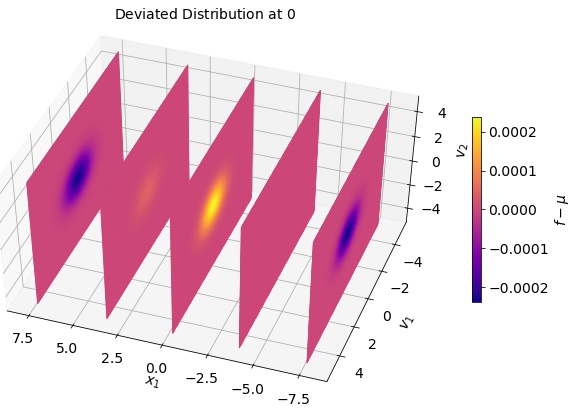

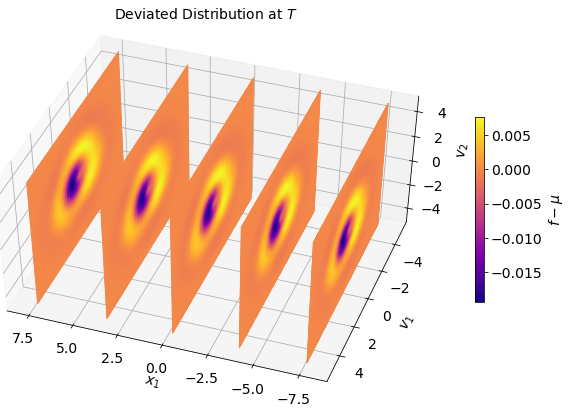

In [17]:
f_iv_nl_np = np.load('f_iv_nonlinear_Gauss_cos04x_siny_alpha00015_beta015_B0_1.npy')

x_slice_indices = np.linspace(1, len(x) - 2, 5, dtype=int)

mu_v = f_Gauss(1, VX, VY) #f_DGH6(VX, VY), f_Gauss(1, VX, VY)  # equilibrium: (Nvx, Nvy)
mu_xv = np.tile(mu_v[None, :, :], (N_x, 1, 1))  # shape: (N_x, Nvx, Nvy)

f_iv_x_np = f_iv_nl_np[:, 8, :, :]  # Fix y index, shape: (N_x, Nvx, Nvy)

f_iv_xv_diff = (f_iv_x_np - mu_xv)  # deviation from equilibrium
vmin = f_iv_xv_diff.min()
vmax = f_iv_xv_diff.max()
norm = colors.Normalize(vmin=vmin, vmax=vmax)

fig = plt.figure(figsize=(8.5, 6))
ax = fig.add_subplot(111, projection='3d')

for i, ix in enumerate(x_slice_indices):
    x_val = x[ix]
    slice_2d = f_iv_xv_diff[ix, :, :]
    ax.plot_surface(np.full_like(VY, x_val), VX, VY, rstride=1, cstride=1,
                    facecolors=cm.plasma(norm(slice_2d)), shade=False)
ax.set_xlabel(r'$x_1$')
ax.set_ylabel(r'$v_1$')
ax.set_zlabel(r'$v_2$')
ax.set_title(r'Deviated Distribution at $0$')
ax.view_init(elev=45, azim=113)
sm = plt.cm.ScalarMappable(cmap='plasma', norm=norm)
sm.set_array([])
cbar = fig.colorbar(sm, ax=ax, shrink=0.5, pad=0.15)
cbar.set_label(r'$f-\mu$')

original_get_proj = ax.get_proj  # Save the original projection method

def get_proj_stretched(xscale=1.46, yscale=1.0, zscale=1.0): # Stretch the x-axis using custom projection
    proj = original_get_proj()
    proj[0, 0] *= xscale  
    proj[1, 1] *= yscale
    proj[2, 2] *= zscale  
    return proj

ax.auto_scale_xyz([x.min(), x.max()], [vx.min(), vx.max()], [vy.min(), vy.max()])

# Override the projection
ax.get_proj = lambda: get_proj_stretched(xscale=1.46)
plt.savefig('fiv_stack_nonlinear_Gauss_cos04x_siny_alpha00015_beta015_B0_1_new.png')
plt.tight_layout()
plt.show()

f_final_nl_np = np.load('f_final_control_param0_Gauss_cos04x_siny_alpha00015_beta015_B0_1.npy')
fxy_vx_np = f_final_nl_np[:,8,:,:]
f_end_xv_diff = (fxy_vx_np - mu_xv) 
vmin = f_end_xv_diff.min()
vmax = f_end_xv_diff.max()
norm = colors.Normalize(vmin=vmin, vmax=vmax)

fig = plt.figure(figsize=(8.5,6))
ax = fig.add_subplot(111, projection='3d')

for i, ix in enumerate(x_slice_indices):
    x_val = x[ix]
    slice_2d = f_end_xv_diff[ix, :, :]
    ax.plot_surface(np.full_like(VY, x_val), VX, VY, rstride=1, cstride=1,
                    facecolors=cm.plasma(norm(slice_2d)),
                    shade=False)
ax.set_xlabel(r'$x_1$')
ax.set_ylabel(r'$v_1$')
ax.set_zlabel(r'$v_2$')
ax.set_title(r'Deviated Distribution at $T$')
ax.view_init(elev=45, azim=113)
sm = plt.cm.ScalarMappable(cmap='plasma', norm=norm)
sm.set_array([])
cbar = fig.colorbar(sm, ax=ax, shrink=0.5, pad=0.15)
cbar.set_label(r'$f-\mu$')

original_get_proj = ax.get_proj  # Save the original projection method

def get_proj_stretched(xscale=1.46, yscale=1.0, zscale=1.0): # Stretch the x-axis using custom projection
    proj = original_get_proj()
    proj[0, 0] *= xscale  
    proj[1, 1] *= yscale
    proj[2, 2] *= zscale  # Leave z
    return proj

ax.auto_scale_xyz([x.min(), x.max()], [vx.min(), vx.max()], [vy.min(), vy.max()])

ax.get_proj = lambda: get_proj_stretched(xscale=1.46) # Override the projection
plt.savefig('fend_stack_control_param0_Gauss_cos04x_siny_alpha00015_beta015_B0_1_new.png')
plt.tight_layout()
plt.show()

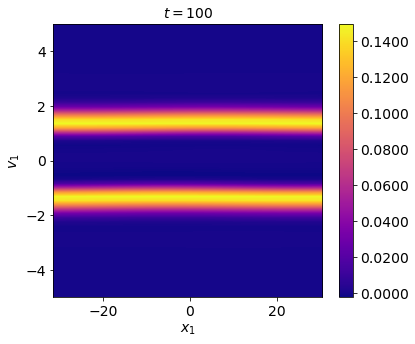

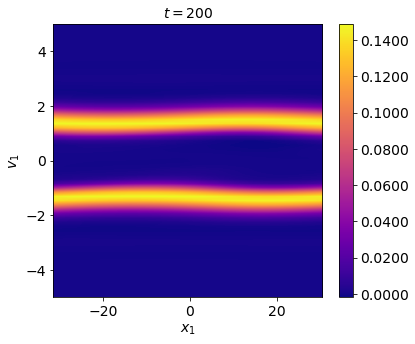

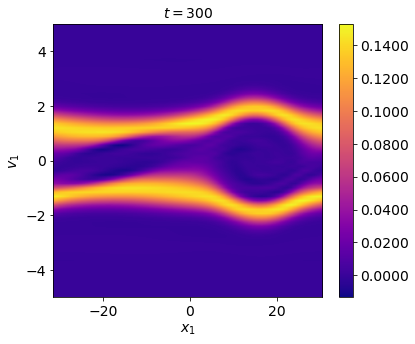

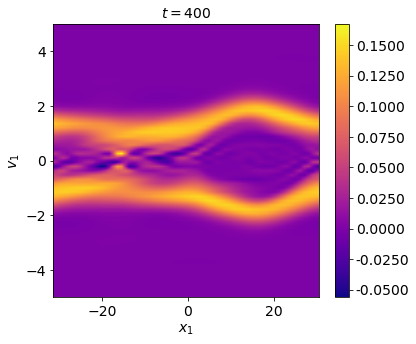

In [13]:
fx_vx = fx_vx_nl_np[999]
fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(fx_vx.T, origin='lower', extent=(x[0], x[-1], vx[0], vx[-1]),
               cmap="plasma", aspect='auto', interpolation='bilinear')
cbar = fig.colorbar(im, ax=ax)
cbar.ax.yaxis.set_major_formatter(FormatStrFormatter('%.4f'))
ax.set_xlabel(r"$x_1$")
ax.set_ylabel(r"$v_1$")
ax.set_title(r'$t=100$')
fig.tight_layout()


In [ ]:
### MOVIES
# distribution movie
f_slices_np = np.array(f_slices_nl)
f_slices_norm = []
for i in range(N_steps):
    f_now = f_slices_np[i]
    rho_now = jnp.sum(f_now, axis=(0, 1)) * dvx * dvy
    norm_f = f_now / rho_now
    f_slices_norm.append(np.array(norm_f)) 
f_slices_norm_np = np.array(f_slices_norm)

fig, ax = plt.subplots(figsize=(10, 8))
im = ax.imshow(f_slices_norm_np[0].T, origin='lower', extent=(vx[0], vx[-1], vy[0], vy[-1]),
               cmap="plasma", aspect='auto', interpolation='bilinear')
cbar = fig.colorbar(im, ax=ax)
cbar.set_label(r"$\bar{f}$")
ax.set_xlabel(r"$v_x$")
ax.set_ylabel(r"$v_y$")
fig.tight_layout()

def update(frame):
    im.set_data(f_slices_norm_np[frame].T)
    ax.set_title(f"Time step {frame}")
    return [im]
ani = animation.FuncAnimation(fig, update, frames=N_steps, interval=40, blit=True)
#ani.save("fv_evolve_DGH6_alpha00001_k010_norm.mp4", writer="ffmpeg", dpi=200)
plt.show()

## slice movie
fx_vx_np = np.array(fx_vx_nl)
fx_vx_ic = fx_vx_np[0]
fig, ax = plt.subplots(figsize=(10, 8))
im = ax.imshow(fx_vx_ic.T, origin='lower', extent=(x[0], x[-1], vx[0], vx[-1]),
               cmap="plasma", aspect='auto', interpolation='bilinear')
cbar = fig.colorbar(im, ax=ax)
cbar.set_label(r"$f(x,v_x)$")
ax.set_xlabel(r"$x$")
ax.set_ylabel(r"$v_x$")
ax.set_title(r"Evolution of $f(x,v_x)$")
fig.tight_layout()

def update(frame):
    im.set_data(fx_vx_np[frame].T)
    ax.set_title(f"Time step {frame}")
    return [im]
ani = animation.FuncAnimation(fig, update, frames=N_steps, interval=25, blit=True)
#ani.save("fx_vx_evolve_DGH6_sinx_alpha0001_T500.mp4", writer="ffmpeg", dpi=200)
plt.show()

## density movie
rho_xy_np = np.array(rho_xy)
rho_xy_ic = rho_xy_np[0]
fig, ax = plt.subplots(figsize=(10, 8))
im = ax.imshow(rho_xy_ic.T, origin='lower', extent=(x[0], x[-1], y[0], y[-1]),
               cmap="viridis", aspect='auto', interpolation='bilinear')
cbar = fig.colorbar(im, ax=ax)
cbar.set_label(r"$\rho$")
ax.set_xlabel(r"$x$")
ax.set_ylabel(r"$y$")
fig.tight_layout()

def update(frame):
    im.set_data(rho_xy_np[frame].T)
    ax.set_title(f"Time step {frame}")
    return [im]
ani = animation.FuncAnimation(fig, update, frames=N_steps, interval=40, blit=True)
#ani.save("rho_xy_evolve_DGH6_alpha00001_k016.mp4", writer="ffmpeg", dpi=200)
plt.show()


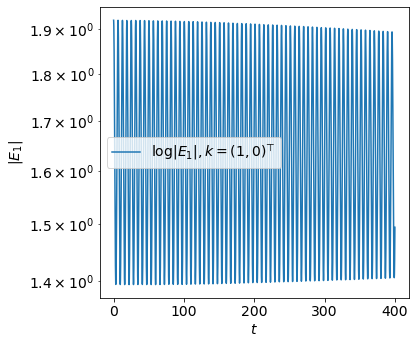

Estimated Landau damping rate for E_x Fourier Mode: 0.00004


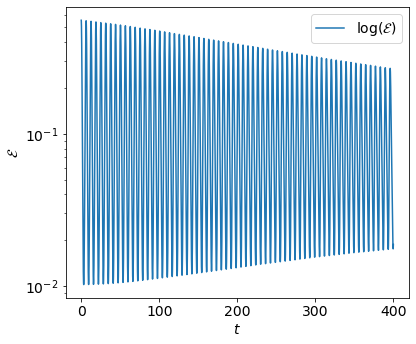

Estimated Landau damping rate for Electric Energy: 0.0019


In [55]:
## Precompute control electric field
from jax.scipy.special import hyp1f1, factorial
from scipy.special import j0

def precompute_delta_tt(delta_t, N_free):
    delta_tt = jnp.zeros((N_free + 1, 1)) #j
    #delta_tt[0] = 1 / delta_t
    #delta_tt[1] = 1 / delta_t
    delta_tt = delta_tt.at[0].set(1 / delta_t)
    delta_tt = delta_tt.at[1].set(1 / delta_t)
    return delta_tt

def delta_approx(t, delta_t, delta_tt):
    N_t0 = jnp.array(t / delta_t, int) 
    delta_t_approx = delta_tt[N_t0]
    return delta_t_approx

def tilde_R_norm_k(k1, k2, t, B0):
    k_abs = jnp.sqrt(k1**2 + k2**2)
    scale = jnp.sqrt(2.0 * (1.0 - jnp.cos(B0 * t))) / B0
    return scale * k_abs

def j0_approx_safe(z, N=10):
    def series(z):
        k = jnp.arange(N + 1)
        factorial_k = factorial(k)
        z = z[:, None]
        k = k[None, :]
        powers = jnp.power(z / 2, 2 * k)
        coeffs = (-1.0)**k / (factorial_k**2)
        terms = coeffs * powers
        return jnp.sum(terms, axis=1)
    def asymptotic(z):
        return jnp.sqrt(2.0 / (jnp.pi * z)) * jnp.cos(z - jnp.pi / 4)

    return jnp.where(z < 10, series(z), asymptotic(z))


def mu_hat_numeric(k1, k2, t, B0):
    j = 6
    alpha_perp = jnp.sqrt(2.0 / j)
    norm_Rk = tilde_R_norm_k(k1, k2, t, B0)
    z = (alpha_perp ** 2) * (norm_Rk ** 2) / 4
    
    def M_series(z):
        return (1 - 6*z + (15/2)*z**2 - (10/3)*z**3 + (5/8)*z**4 - (1/20)*z**5 + (1/720)*z**6)
    
    M_vals = M_series(z)
    exp_val = jnp.exp(-z)
    mu_hat_R = exp_val * M_vals
    
    return mu_hat_R


@jit
def H_hat(t, delta_t, K1, K2, B_0, hx_param, delta_tt):
    j = 6
    z = -(1 - jnp.cos(B_0 * t)) * (K1**2 + K2**2) / (j * B_0**2)
    #mu_hat_DGH6 = mu_hat_numeric(K1, K2, t, B_0)
    
    Nx, Ny = K1.shape
    k1_flat, k2_flat = K1.reshape(-1), K2.reshape(-1) # Flatten grid

    # Vectorize mu_hat_numeric over (k1_flat, k2_flat)
    mu_flat = vmap(lambda k1, k2: mu_hat_numeric(k1, k2, t, B_0))(k1_flat, k2_flat)

    mu_hat_DGH6 = mu_flat.reshape((Nx, Ny)) # Reshape back to (Nx, Ny)
    #z = jnp.clip(z, -25, 0)  # Prevent large negative z
    #mu_hat_DGH6 = hyp1f1(j+1, 1, z)
    #mu_hat_DGH6 = hyp1f1(j+1, 1, -(1 - jnp.cos(B_0 * t)) * (K1**2 + K2**2) / (j * B_0 * B_0))
    #mu_hat_DGH6 = compute_mu_numeric_loop(K1, K2, t, B_0)
    # theta = 5 mu_hat_gauss = jnp.exp(- 0.5 * theta * (K1**2 + K2**2))
    mu_hat = mu_hat_DGH6.real # jnp.fft.ifftshift(mu_hat_gauss.real)

    term1 = hx_param * delta_approx(t, delta_t, delta_tt) 
    term2 = hx_param * mu_hat * jnp.sin(B_0 * t) / B_0  
    sum_term = term1 + term2

    Hx_hat = jnp.fft.ifftshift(-1j * K1 * sum_term) 
    Hy_hat = jnp.fft.ifftshift(-1j * K2 * sum_term) 
    return Hx_hat, Hy_hat

@jit
def compute_H(t, E_f1, E_f2, K1, K2, B_0, hx_param, delta_t, delta_tt):
    Hx_hat, Hy_hat = H_hat(t, delta_t, K1, K2, B_0, hx_param, delta_tt)
    H_x = jnp.real(jnp.fft.fftshift(jnp.fft.ifft2(Hx_hat))) / (dx * dy) - E_f1 
    H_y = jnp.real(jnp.fft.fftshift(jnp.fft.ifft2(Hy_hat))) / (dx * dy) - E_f2 
    return H_x, H_y


def compute_mu_numeric_loop(K1, K2, t, B0):
    Nx, Ny = K1.shape
    mu = np.zeros((Nx, Ny)) #j
    for i in range(Nx):
        for j in range(Ny):
            val = mu_hat_numeric(K1[i, j], K2[i, j], t, B0)
            mu[i,j] = val  #mu = mu.at[i, j].set(val)
    return mu

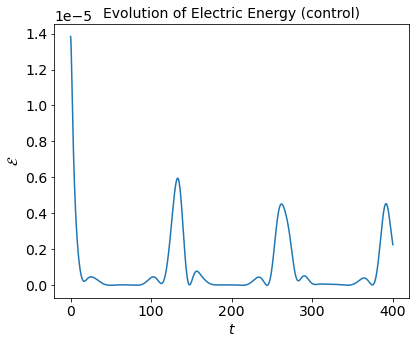

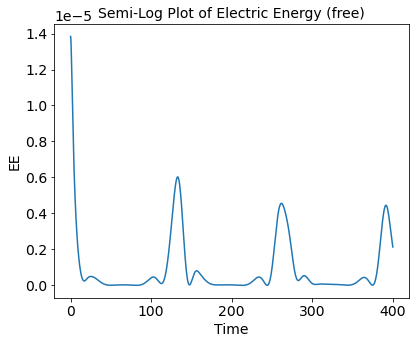

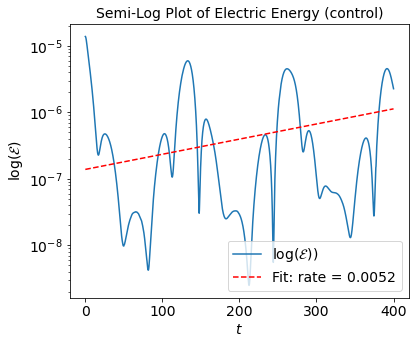

Estimated Landau damping rate for Electric Energy: -0.0052


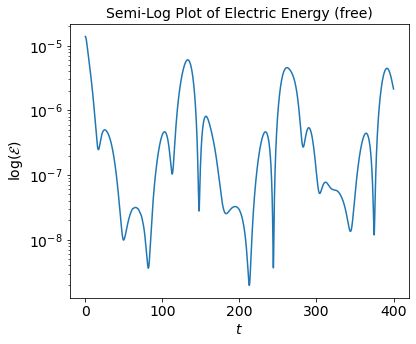

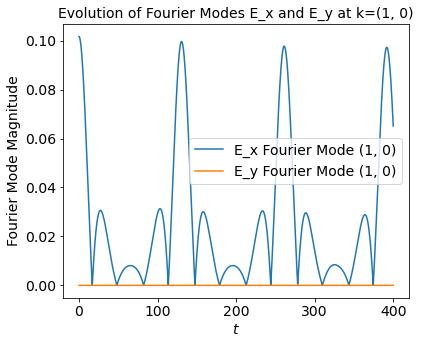

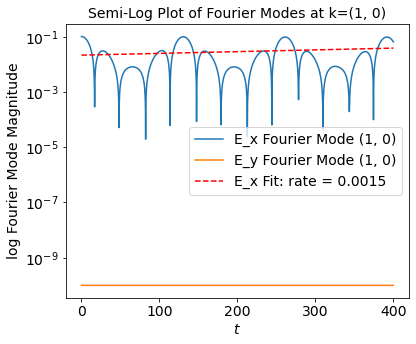

Estimated Landau damping rate for E_x Fourier Mode: -0.0015


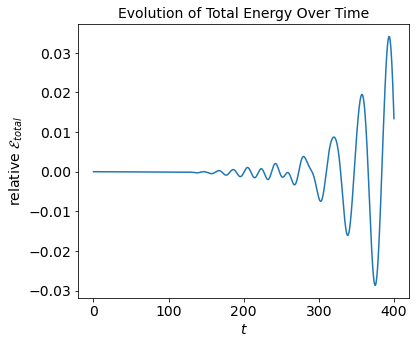

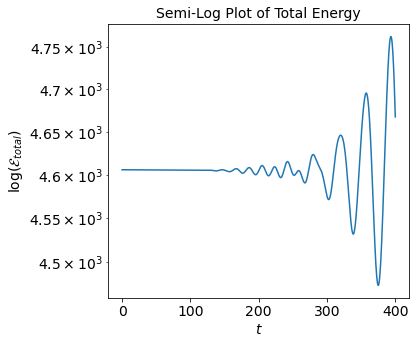

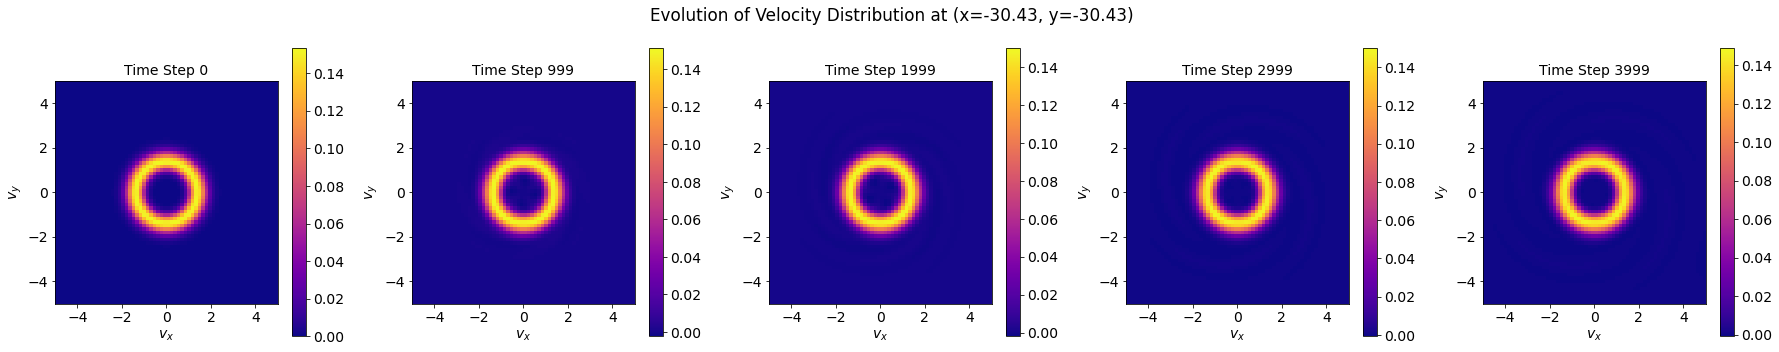

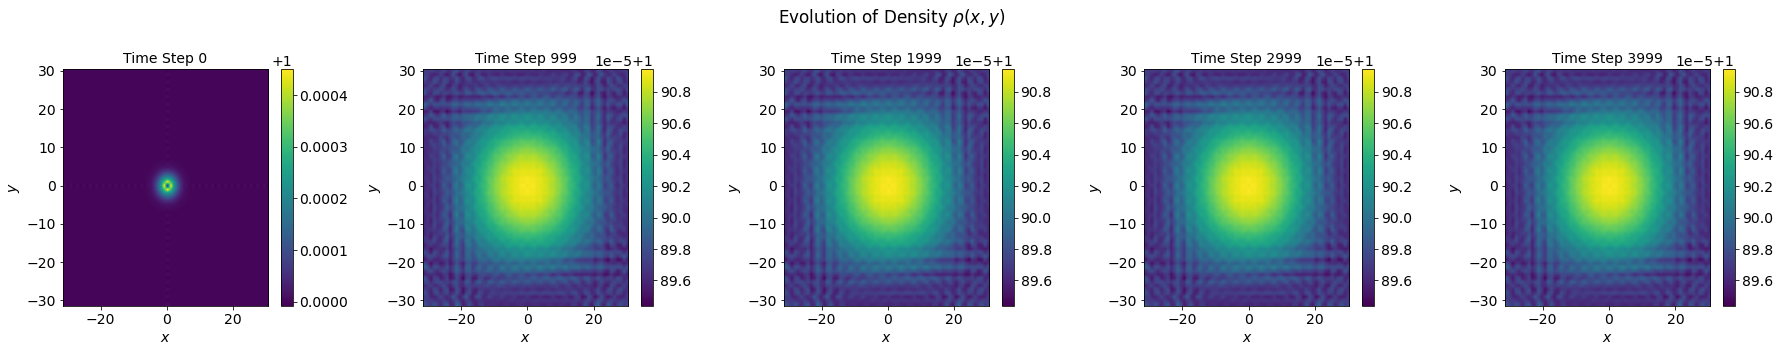

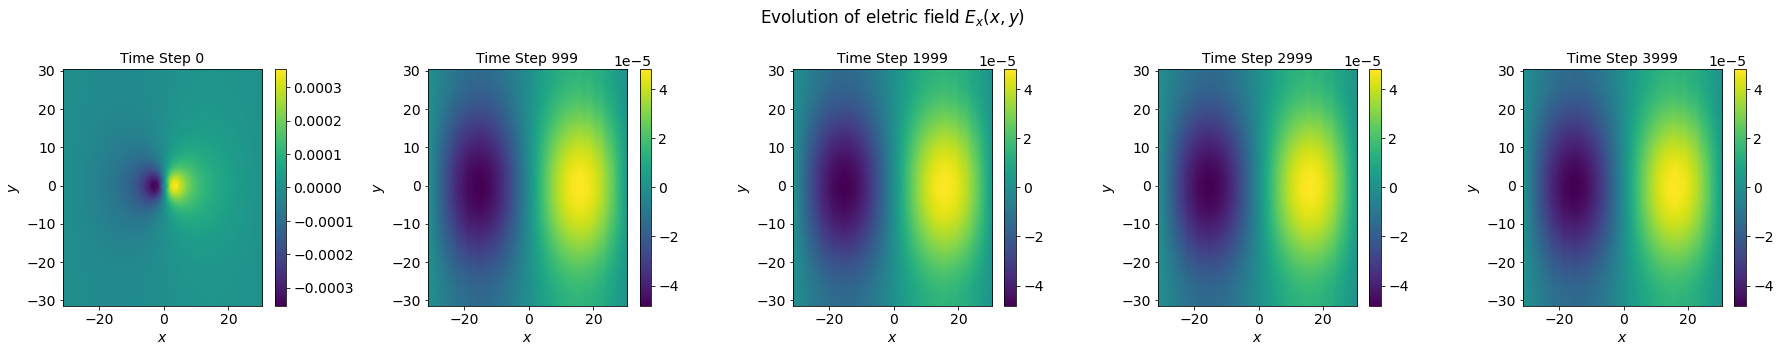

In [62]:
### CONTROL SIMULATION
# 1. Parameters
kx, ky = 0.10, 0.10   # DGH6: 0.10, 0.10, KH-Gaussian: 0.40, 1.0
alpha, beta = 0.01, 0.15       
L_x, L_y = 2.0 * jnp.pi / kx, 2.0 * jnp.pi / ky 
N_x, N_y = 64, 64      
N_vx, N_vy = 64, 64
Vx_max, Vy_max = 5.0, 5.0    
delta_t = 0.1  
N_steps = 4000
t_values = jnp.linspace(0, delta_t * N_steps, N_steps+1)
t_values_np = np.array(t_values)
time_array = t_values_np 
N_snaps = 5
k_track = (1, 0)  # Fourier mode to track
epsilon = 1e-10   # Small epsilon to prevent log(0)
    
# 2. Generate Spatial and Velocity Grids
x = jnp.linspace(-0.5 * L_x, 0.5 * L_x, N_x, endpoint=False)  
y = jnp.linspace(-0.5 * L_y, 0.5 * L_y, N_y, endpoint=False) 
vx, vy = jnp.linspace(-Vx_max, Vx_max, N_vx), jnp.linspace(-Vy_max, Vy_max, N_vy)
    
dx, dy = x[1] - x[0], y[1] - y[0]
dvx, dvy = vx[1] - vx[0], vy[1] - vy[0]
    
# 3. **Create Meshgrids for Spatial and Velocity Coordinates**
X, Y = jnp.meshgrid(x, y, indexing='ij')       # Shape: [N_x, N_y]
VX, VY = jnp.meshgrid(vx, vy, indexing='ij')   # Shape: [N_vx, N_vy]

k1 = jnp.fft.fftshift(jnp.fft.fftfreq(N_x, d=dx)) * (2*jnp.pi)
k2 = jnp.fft.fftshift(jnp.fft.fftfreq(N_y, d=dy)) * (2*jnp.pi)
k1_grid, k2_grid = jnp.meshgrid(k1, k2, indexing='ij')
K1_grid_np, K2_grid_np = np.array(k1_grid), np.array(k2_grid)
    
X_expanded, Y_expanded = X[:, :, None, None], Y[:, :, None, None] # [N_x, N_y, 1, 1]
VX_expanded, VY_expanded = VX[None, None, :, :], VY[None, None, :, :]

# 4. Initial Distribution f_iv
# f_iv = (1 + alpha*jnp.cos(kx * X_expanded) + beta * jnp.sin(ky * Y_expanded)) * f_Gauss(1, VX_expanded, VY_expanded)  
xr = X_expanded**2 + Y_expanded**2
theta = 4
gauss_x = (1 / (2 * jnp.pi * theta)) * jnp.exp(- xr/(2*theta))
f_iv = (1 + 0.01*gauss_x)* f_DGH6(VX_expanded, VY_expanded) 
#f_iv = (1 + alpha*jnp.sin(kx * X_expanded)) * f_DGH6(VX_expanded, VY_expanded)

# 5. Define External Magnetic Field B
B_0 = 0.05 # DGH6: 0.05, KH-Gaussian: 1.0
B_external = jnp.ones((N_x, N_y)) * B_0 
    
# 6. free-sreaming 
(f_free, _, _, _, _, _, _, _, history_E_free, history_U_free, _, history_EE_free, _, f_last_snap) = run_solver_free_streaming(
        f_iv, 
        grid_x=x, grid_y=y, grid_vx=vx, grid_vy=vy,
        delta_t=delta_t, N_steps=N_steps, N_snaps=N_snaps, k_track=k_track, B_external=B_external) 
Ex_free, Ey_free = history_E_free[1:, :, :, 0], history_E_free[1:, :, :, 1]
Ex_free_np, Ey_free_np = np.array(Ex_free), np.array(Ey_free)
history_EE_free_np = np.array(history_EE_free)

# 7. Build control electric field 
hx_param = 0.001
delta_tt = precompute_delta_tt(delta_t, N_steps)
compute_H_seq = vmap(
     lambda t, Ef1, Ef2: compute_H(t, Ef1, Ef2, k1_grid, k2_grid, B_0, hx_param, delta_t, delta_tt),
     in_axes=(0, 0, 0) )
Hx, Hy = compute_H_seq(t_values[1:], Ex_free, Ey_free)

# If complete pole elimination (hx_param=0):
#Hx, Hy = -history_E_free[1:, :, :, 0], -history_E_free[1:, :, :, 1]
#Hx_np, Hy_np = np.array(Hx), np.array(Hy)

# Run the Solver with External electric field
(f_final, f_slice, fx_vx, rho_xy, f_snapshots, rho_snapshots, Ey_snapshots,
 history_E, history_KE, history_EE, history_Fourier) = run_solver_with_external_field_H(
        f_iv,
        grid_x=x, grid_y=y, grid_vx=vx, grid_vy=vy,
        delta_t=delta_t, N_steps=N_steps, N_snaps=N_snaps, k_track=k_track,
        Hx=Hx, Hy=Hy, B_external=B_external)
    
# 8. **Convert JAX Arrays to NumPy for Plotting**
history_E_np = np.array(history_E)        # Shape: [N_steps +1, N_x, N_y, 2]
history_KE_np, history_EE_np = np.array(history_KE), np.array(history_EE)    # Shape: [N_steps +1]
history_TE_np = history_KE_np + history_EE_np  
history_Fourier_np = np.array(history_Fourier) 
f_iv_np, f_final_np, fx_vx_np = np.array(f_iv), np.array(f_final), np.array(fx_vx)
f_slice_np = np.array(f_slice)
rho_xy_np = np.array(rho_xy)

# 11. **Plot Evolution of Electric Energy**
time_array = t_values_np 
plt.figure(figsize=(6, 5))
plt.plot(time_array, history_EE_np) #, label='EE')
plt.xlabel(r'$t$')
plt.ylabel(r'$\mathcal{E}$')
plt.savefig('EE_control_param0001_DGH6_gauss4x_alpha001_B0_005.png') 
# DGH6_sin01x_alpha0001_B0_005, DGH6_gauss4x_alpha001_B0_005  # Gauss_cos04x_siny_alpha00015_beta015_B0_1 
plt.title('Evolution of Electric Energy (control)')
plt.tight_layout()
plt.show()

plt.figure(figsize=(6, 5))
plt.plot(time_array, history_EE_free_np)
plt.xlabel('Time')
plt.ylabel('EE')
plt.title('Semi-Log Plot of Electric Energy (free)')
plt.tight_layout()
plt.show()

# Semi-Log Plot for Electric Energy 
log_EE = np.log(history_EE_np + epsilon)
peaks, _ = find_peaks(log_EE)
log_EE_fit, tt_fit = log_EE[peaks], time_array[peaks]
slope_EE, intercept_EE, _, _, _ = linregress(tt_fit, log_EE_fit) # Fit linear decay in log scale
decay_rate_EE = -slope_EE  # Damping rate
fitted_EE = intercept_EE + slope_EE * time_array # Generate fitted line

plt.figure(figsize=(6, 5))
plt.semilogy(time_array, history_EE_np + epsilon, label=r'$\log(\mathcal{E}))$')
plt.plot(time_array, np.exp(fitted_EE), 'r--', label=f'Fit: rate = {slope_EE:.4f}')
plt.xlabel(r'$t$')
plt.ylabel(r'$\log(\mathcal{E})$')
plt.legend()
# plt.savefig('logEE_control_param0001_DGH6_gauss4x_alpha001_B0_005.png')
plt.title('Semi-Log Plot of Electric Energy (control)')
plt.tight_layout()
plt.show()
print(f"Estimated Landau damping rate for Electric Energy: {decay_rate_EE:.4f}")

plt.figure(figsize=(6, 5))
plt.semilogy(time_array, history_EE_free_np + epsilon)
plt.xlabel(r'$t$')
plt.ylabel(r'$\log(\mathcal{E})$')
plt.title('Semi-Log Plot of Electric Energy (free)')
plt.tight_layout()
plt.show()

# 12. **Plot Evolution of Tracked Fourier Modes**
E_x_mode, E_y_mode = history_Fourier_np[:, 0], history_Fourier_np[:, 1]   # Shape: [N_steps +1]
E_x_modes_mag, E_y_modes_mag = np.abs(E_x_mode), np.abs(E_y_mode)
    
# **Plot Fourier Modes Evolution **
plt.figure(figsize=(6, 5))
plt.plot(time_array, E_x_modes_mag, label=f'E_x Fourier Mode {k_track}')
plt.plot(time_array, E_y_modes_mag, label=f'E_y Fourier Mode {k_track}')
plt.xlabel(r'$t$')
plt.ylabel('Fourier Mode Magnitude')
plt.legend()
# plt.savefig('FE_control_param0001_DGH6_gauss4x_alpha001_B0_005.png')
plt.title(f'Evolution of Fourier Modes E_x and E_y at k={k_track}')
plt.tight_layout()
plt.show()
 
# **Plot Fourier Modes Evolution (Semi-Log Scale) with Decay Rates**
log_E_x = np.log(E_x_modes_mag + epsilon) 
peaks, _ = find_peaks(log_E_x)
log_Ex_fit = log_E_x[peaks] 
tx_fit = time_array[peaks]
slope_Ex, intercept_Ex, _, _, _ = linregress(tx_fit, log_Ex_fit) # Fit linear decay in log scale
decay_rate_Ex = -slope_Ex  # Damping rate
fitted_Ex = intercept_Ex + slope_Ex * time_array # Generate fitted line

plt.figure(figsize=(6, 5))
plt.semilogy(time_array, E_x_modes_mag + epsilon, label=f'E_x Fourier Mode {k_track}')
plt.semilogy(time_array, E_y_modes_mag + epsilon, label=f'E_y Fourier Mode {k_track}')
plt.plot(time_array, np.exp(fitted_Ex), 'r--', label=f'E_x Fit: rate = {slope_Ex:.4f}')

plt.xlabel(r'$t$')
plt.ylabel('log Fourier Mode Magnitude')
plt.legend()
# plt.savefig('logFE_control_param0001_DGH6_gauss4x_alpha001_B0_005.png')
plt.title(f'Semi-Log Plot of Fourier Modes at k={k_track}')
plt.tight_layout()
plt.show()
print(f"Estimated Landau damping rate for E_x Fourier Mode: {decay_rate_Ex:.4f}")

# 13. **Plot Evolution of Total Energy**
initial_TE = history_TE_np[0]
relative_TE = (history_TE_np - initial_TE) / initial_TE

plt.figure(figsize=(6, 5))
plt.plot(time_array, relative_TE)
plt.xlabel(r'$t$')
plt.ylabel(r'relative $\mathcal{E}_{total}$')
#plt.savefig('relTE_control_param0001_DGH6_gauss4x_alpha001_B0_005.png')
plt.title('Evolution of Total Energy Over Time')
plt.tight_layout()
plt.show()

plt.figure(figsize=(6, 5)) # Semi-Log Plot for Total Energy 
plt.semilogy(time_array, history_TE_np + epsilon) #, label='Total Energy (Log Scale)')
plt.xlabel(r'$t$')
plt.ylabel(r'$\log(\mathcal{E}_{total})$')
#plt.savefig('logTE_control_param001_DGH6_gauss4x_alpha0001_B0_005.png')
plt.title('Semi-Log Plot of Total Energy')
plt.tight_layout()
plt.show()

rho_xy_np = np.array(rho_xy)
rho_xy_ic = rho_xy_np[3999]
fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(rho_xy_ic.T, origin='lower', extent=(x[0], x[-1], y[0], y[-1]),
               cmap="viridis", aspect='auto', interpolation='bilinear')
cbar = fig.colorbar(im, ax=ax)
cbar.ax.yaxis.set_major_formatter(FormatStrFormatter('%.4f'))
ax.set_xlabel(r"$x_1$")
ax.set_ylabel(r"$x_2$")
fig.tight_layout()
ax.set_title(r"$\rho(x_1,x_2)$ at $t=400$")
# plt.savefig('rho_xy_control_param0_DGH6_gauss4x_alpha001_B0_005_t400.png')
fig.tight_layout()

fx_vx_np = np.array(fx_vx)
fx_vx_ic = fx_vx_np[3749]
fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(fx_vx_ic.T, origin='lower', extent=(x[0], x[-1], vx[0], vx[-1]),
               cmap="plasma", aspect='auto', interpolation='bilinear')
cbar = fig.colorbar(im, ax=ax)
cbar.set_label(r"$f(x_1,v_1)$")
ax.set_xlabel(r"$x_1$")
ax.set_ylabel(r"$v_1$")
ax.set_title(r"$f(x_1,v_1)$ at $t=375$")
# plt.savefig('f_xvx_control_param0_DGH6_gauss4x_alpha001_B0_005_t375.png')
fig.tight_layout()

f_slices_np = np.array(f_slice)
fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(f_slices_np[3999].T, origin='lower', extent=(vx[0], vx[-1], vy[0], vy[-1]),
               cmap="plasma", aspect='auto', interpolation='bilinear')
cbar = fig.colorbar(im, ax=ax)
cbar.set_label(r"$f$")
ax.set_xlabel(r"$v_1$")
ax.set_ylabel(r"$v_2$")
ax.set_title(r"$f(v_1,v_2)$ at $t=400$")
#plt.savefig('f_vxvy_control_param0_DGH6_gauss4x_alpha001_B0_005_t400.png')
fig.tight_layout()

# 14. **Plot Distribution Function at Selected (x, y) Points**
x0_idx, y0_idx = 1, 1 
time_intervals, snapshot_indices = np.linspace(0, N_snaps, num=N_snaps, dtype=int), jnp.linspace(0, N_steps - 1, N_snaps, dtype=int) 

f_velocity_history = []
for t in time_intervals:
    f_velocity_history.append(f_snapshots[t][x0_idx, y0_idx, :, :])  
f_velocity_history = np.array(f_velocity_history) 

fig, axes = plt.subplots(1, N_snaps, figsize=(25, 5))
for i, ax in enumerate(axes.flatten()):
        cs = ax.imshow(f_velocity_history[i].T, extent=[vx[0], vx[-1], vy[0], vy[-1]], origin='lower', cmap='plasma')
        ax.set_title(f'Time Step {snapshot_indices[i]}')
        ax.set_xlabel(r'$v_x$')
        ax.set_ylabel(r'$v_y$')
        fig.colorbar(cs, ax=ax)
plt.suptitle(f'Evolution of Velocity Distribution at (x={x[x0_idx]:.2f}, y={y[y0_idx]:.2f})')
#plt.savefig('fsnaps_control_param001_DGH6_gauss4x_alpha0001_B0_005.png')
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(1, N_snaps, figsize=(25, 5))  # 1 row, N_snaps columns
for i in range(N_snaps):
        ax = axes[i]  
        idx = snapshot_indices[i]
        im = ax.imshow(rho_snapshots[idx].T, origin='lower', extent=(x[0], x[-1], y[0], y[-1]),
               cmap="viridis", aspect='auto', interpolation='bilinear')
        cbar = fig.colorbar(im, ax=ax)
        ax.set_xlabel(r'$x$')
        ax.set_ylabel(r'$y$')
        ax.set_title(f'Time Step {snapshot_indices[i]}')
plt.suptitle(r'Evolution of Density $\rho(x,y)$')
#plt.savefig('rhosnap_control_param001_DGH6_gauss4x_alpha0001_B0_005.png')
plt.tight_layout()
plt.show()
    
fig, axes = plt.subplots(1, N_snaps, figsize=(25, 5))  
for i in range(N_snaps):
        ax = axes[i]  
        idx = snapshot_indices[i] 
        im = ax.imshow(Ey_snapshots[idx].T, origin='lower', extent=(x[0], x[-1], y[0], y[-1]),
               cmap="viridis", aspect='auto', interpolation='bilinear')
        cbar = fig.colorbar(im, ax=ax)
        ax.set_xlabel(r'$x$')
        ax.set_ylabel(r'$y$')
        ax.set_title(f'Time Step {snapshot_indices[i]}')
plt.suptitle(r'Evolution of eletric field $E_x(x,y)$')
#plt.savefig('Ex_control_param001_DGH6_gauss4x_alpha0001_B0_005.png')
plt.tight_layout()
plt.show()

# Save outputs to file

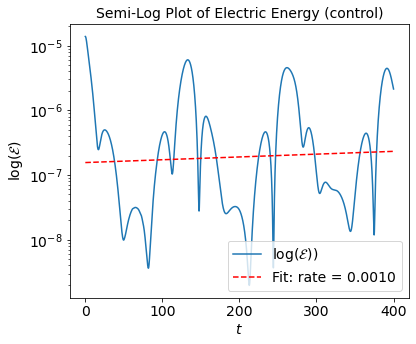

Estimated Landau damping rate for Electric Energy: -0.0010


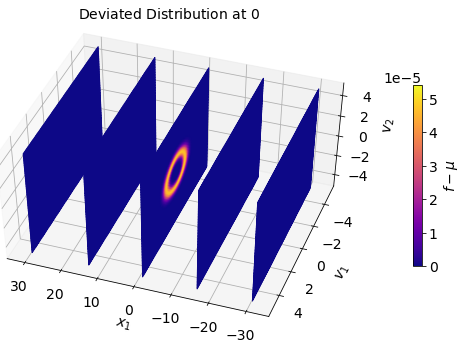

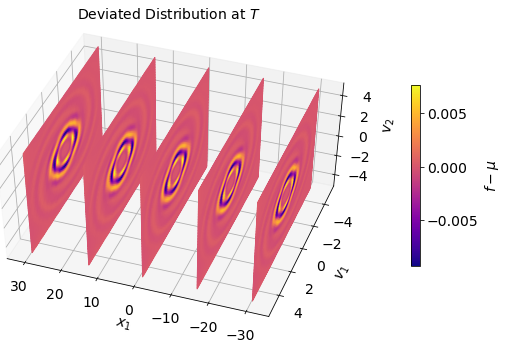

In [63]:
## plot slices-in-x in deviation of f(vx, vy)  

x_slice_indices = np.linspace(1, len(x) - 2, 5, dtype=int)

mu_v = f_DGH6(VX, VY) #f_Gauss(1, VX, VY)  #f_DGH6(VX, VY)  # equilibrium: (Nvx, Nvy)
mu_xv = np.tile(mu_v[None, :, :], (N_x, 1, 1))  # shape: (N_x, Nvx, Nvy)

f_iv_x_np = f_iv_np[:, 31, :, :]  # Fix y index, shape: (N_x, Nvx, Nvy)

f_iv_xv_diff = (f_iv_x_np - mu_xv)  # deviation from equilibrium
vmin = f_iv_xv_diff.min()
vmax = f_iv_xv_diff.max()
norm = colors.Normalize(vmin=vmin, vmax=vmax)

fig = plt.figure(figsize=(9, 5))
ax = fig.add_subplot(111, projection='3d')

for i, ix in enumerate(x_slice_indices):
    x_val = x[ix]
    slice_2d = f_iv_xv_diff[ix, :, :]
    ax.plot_surface(np.full_like(VY, x_val), VX, VY, rstride=1, cstride=1,
                    facecolors=cm.plasma(norm(slice_2d)), shade=False)
ax.set_xlabel(r'$x_1$')
ax.set_ylabel(r'$v_1$')
ax.set_zlabel(r'$v_2$')
ax.set_title(r'Deviated Distribution at $0$')
ax.view_init(elev=45, azim=113)
sm = plt.cm.ScalarMappable(cmap='plasma', norm=norm)
sm.set_array([])
cbar = fig.colorbar(sm, ax=ax, shrink=0.6, pad=0.15)
cbar.set_label(r'$f-\mu$')

original_get_proj = ax.get_proj  # Save the original projection method

def get_proj_stretched(xscale=1.46, yscale=1.0, zscale=1.0): # Stretch the x-axis using custom projection
    proj = original_get_proj()
    proj[0, 0] *= xscale  
    proj[1, 1] *= yscale
    proj[2, 2] *= zscale  
    return proj

ax.auto_scale_xyz([x.min(), x.max()], [vx.min(), vx.max()], [vy.min(), vy.max()])

# Override the projection
ax.get_proj = lambda: get_proj_stretched(xscale=1.46)
plt.savefig('fiv_stack_control_param0001_DGH6_gauss4x_alpha001_B0_005.png')
plt.tight_layout()
plt.show()

fxy_vx_np = f_final_np[:,31,:,:]
f_end_xv_diff = (fxy_vx_np - mu_xv) 
vmin = f_end_xv_diff.min()
vmax = f_end_xv_diff.max()
norm = colors.Normalize(vmin=vmin, vmax=vmax)

fig = plt.figure(figsize=(9,5))
ax = fig.add_subplot(111, projection='3d')

for i, ix in enumerate(x_slice_indices):
    x_val = x[ix]
    slice_2d = f_end_xv_diff[ix, :, :]
    ax.plot_surface(np.full_like(VY, x_val), VX, VY, rstride=1, cstride=1,
                    facecolors=cm.plasma(norm(slice_2d)),
                    shade=False)
ax.set_xlabel(r'$x_1$')
ax.set_ylabel(r'$v_1$')
ax.set_zlabel(r'$v_2$')
ax.set_title(r'Deviated Distribution at $T$')
ax.view_init(elev=45, azim=113)
sm = plt.cm.ScalarMappable(cmap='plasma', norm=norm)
sm.set_array([])
cbar = fig.colorbar(sm, ax=ax, shrink=0.6, pad=0.15)
cbar.set_label(r'$f-\mu$')

# === Stretch the x-axis using custom projection ===
original_get_proj = ax.get_proj  # Save the original projection method

def get_proj_stretched(xscale=1.46, yscale=1.0, zscale=1.0):
    proj = original_get_proj()
    proj[0, 0] *= xscale  
    proj[1, 1] *= yscale
    proj[2, 2] *= zscale  # Leave z
    return proj

ax.auto_scale_xyz([x.min(), x.max()], [vx.min(), vx.max()], [vy.min(), vy.max()])

ax.get_proj = lambda: get_proj_stretched(xscale=1.46) 
#plt.savefig('fend_stack_control_param0001_DGH6_gauss4x_alpha001_B0_005.png')
plt.tight_layout()
plt.show()

In [ ]:
## distribution movie
f_slices_np = np.array(f_slice)
f_slices_norm = []
for i in range(N_steps):
    f_now = f_slices_np[i]
    rho_now = jnp.sum(f_now, axis=(0, 1)) * dvx * dvy
    norm_f = f_now / rho_now
    f_slices_norm.append(norm_f)  
f_slices_norm_np = np.array(f_slices_norm)

fig, ax = plt.subplots(figsize=(10, 8))
im = ax.imshow(f_slices_norm_np[10].T, origin='lower', extent=(vx[0], vx[-1], vy[0], vy[-1]),
               cmap="plasma", aspect='auto', interpolation='bilinear')
cbar = fig.colorbar(im, ax=ax)
cbar.set_label(r"$\bar{f}$")
ax.set_xlabel(r"$v_x$")
ax.set_ylabel(r"$v_y$")
ax.set_title(r"Evolution of $\bar{f}$")
fig.tight_layout()

def update(frame):
    im.set_data(f_slices_norm_np[frame].T)
    ax.set_title(f"Time step {frame}")
    return [im]
ani = animation.FuncAnimation(fig, update, frames=N_steps, interval=100, blit=True)
#ani.save("fv_evolve_DGH6_control_alpha01_k01_norm.mp4", writer="ffmpeg", dpi=200)
plt.show()

## fx_vx slice movie
fx_vx_np = np.array(fx_vx)
fx_vx_ic = fx_vx_np[0]
fig, ax = plt.subplots(figsize=(10, 8))
im = ax.imshow(fx_vx_ic.T, origin='lower', extent=(x[0], x[-1], vx[0], vx[-1]),
               cmap="plasma", aspect='auto', interpolation='bilinear')
cbar = fig.colorbar(im, ax=ax)
cbar.set_label(r"$f(x,v_x)$")
ax.set_xlabel(r"$x$")
ax.set_ylabel(r"$v_x$")
ax.set_title(r"Evolution of $f(x,v_x)$")
fig.tight_layout()

def update(frame):
    im.set_data(fx_vx_np[frame].T)
    ax.set_title(f"Time step {frame}")
    return [im]
ani = animation.FuncAnimation(fig, update, frames=N_steps, interval=100, blit=True)
#ani.save("fx_vx_evolve_DGH6_control_alpha01_k01.mp4", writer="ffmpeg", dpi=200)
plt.show()

## density movie
rho_xy_np = np.array(rho_xy)
rho_xy_ic = rho_xy_np[0]
fig, ax = plt.subplots(figsize=(10, 8))
im = ax.imshow(rho_xy_ic.T, origin='lower', extent=(x[0], x[-1], y[0], y[-1]),
               cmap="viridis", aspect='auto', interpolation='bilinear')
cbar = fig.colorbar(im, ax=ax)
cbar.set_label(r"$\rho(x,y)$")
ax.set_xlabel(r"$x$")
ax.set_ylabel(r"$y$")
ax.set_title(r"Evolution of $\rho(x,y)$")
fig.tight_layout()

def update(frame):
    im.set_data(rho_xy_np[frame].T)
    ax.set_title(f"Time step {frame}")
    return [im]

ani = animation.FuncAnimation(fig, update, frames=N_steps, interval=100, blit=True)
#ani.save("rho_xy_evolve_DGH6_control_alpha01_k01.mp4", writer="ffmpeg", dpi=200)
plt.show()

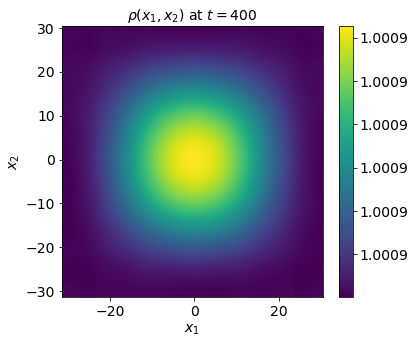

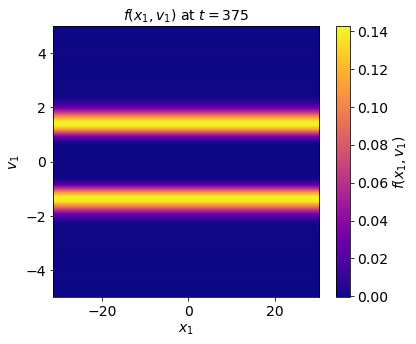

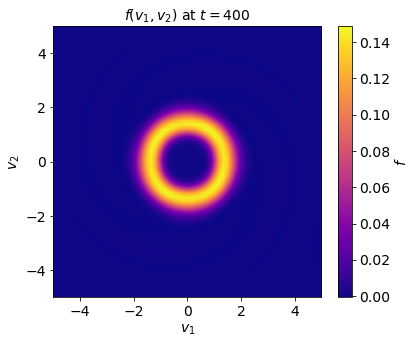